    # ⚡ KPLC Langata Substation — Power Outage Prediction System
    ### Hybrid ML Framework for Outage Prediction and Reliability Analysis

    ---
    | | |
    |---|---|
    | **Student** | Dinero · SCT213-C002-0073/2022 |
    | **Supervisor** | Dr. Adhola |
    | **Institution** | JKUAT — BSc Data Science & Analytics |
    | **Period** | February – June 2026 · Methodology: CRISP-DM |
    | **Data Partner** | KPLC — Langata 66kV/11kV Substation |

    ---
    ### Architecture
    ```
    STAGE 1 — Will an outage occur? (feeder-day grain, 7-day ahead)
      SARIMA (×6 feeders) ──┐
      Prophet (×8 feeders) ──┼──► Ensemble ──► Probability ≥ 0.30?
      XGBoost + RF          ──┘                     │ YES
                                                     ▼
    STAGE 2 — What fault type? (event grain)
      XGBoost 3-class ──► Loss of Supply / Controlled / Physical Fault
                                                     │
                                                     ▼
                                  Crew dispatch recommendation
    ```
    | § | Phase | Content |
    |---|---|---|
    | 0 | Setup | Drive · dependencies · constants |
    | 1 | Business Understanding | Objectives · success criteria |
    | 2 | Data Understanding | EDA across all datasets |
    | 3 | Data Preparation | Feature engineering · two training datasets |
    | 4A | Time Series | SARIMA + Prophet per feeder |
    | 4B | Binary ML | XGBoost + RF binary classifier |
    | 4C | Ensemble | Optimal TS + ML combination |
    | 4D | Fault Classifier | XGBoost 3-class fault type |
    | 4E | Full Pipeline | Chain stages · 7-day forecast |
    | 5 | Evaluation | Metrics · SHAP · SAIFI/SAIDI |
    | 6 | Deployment | Export models · dashboard data |
    

---
## ⚙️ Section 0 — Setup
> Run every session before anything else.

### 0.1 — Mount Google Drive

In [ ]:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    print("✅ Google Drive mounted")


Mounted at /content/drive
✅ Google Drive mounted


    ### 0.2 — Project Root
    > **Edit `PROJECT_ROOT` to your Drive folder path.**
    

In [ ]:
    from pathlib import Path

    # ── EDIT THIS ──────────────────────────────────────────────────────
    PROJECT_ROOT = Path("/content/drive/MyDrive/KPLC_Langata_Project")
    # ──────────────────────────────────────────────────────────────────

    PATHS = {
        "raw":       PROJECT_ROOT / "data" / "raw",
        "processed": PROJECT_ROOT / "data" / "processed",
        "models":    PROJECT_ROOT / "models" / "saved",
        "results":   PROJECT_ROOT / "models" / "results",
        "figures":   PROJECT_ROOT / "outputs" / "figures",
        "dashboard": PROJECT_ROOT / "outputs" / "dashboard",
    }
    for p in PATHS.values():
        p.mkdir(parents=True, exist_ok=True)

    required = {
        "raw":       ["incidences_Langata_s_s.xlsx", "weather_daily.csv",
                      "kenya_holidays.csv"],
        "processed": ["feeder_lines.csv", "network_nodes.csv",
                      "feeder_topology.csv"],
    }
    all_ok = True
    for folder, files in required.items():
        for f in files:
            exists = (PATHS[folder] / f).exists()
            if not exists: all_ok = False
            print(f"  {'✅' if exists else '❌ MISSING'}  {folder}/{f}")

    print()
    print("✅ All files present" if all_ok
          else "❌ Upload missing files to Drive before proceeding")


  ✅  raw/incidences_Langata_s_s.xlsx
  ✅  raw/weather_daily.csv
  ✅  raw/kenya_holidays.csv
  ✅  processed/feeder_lines.csv
  ✅  processed/network_nodes.csv
  ✅  processed/feeder_topology.csv

✅ All files present


### 0.3 — Install Dependencies

In [ ]:
    %%capture
    !pip install xgboost prophet optuna shap statsmodels \
                imbalanced-learn openpyxl ezdxf pyproj \
                plotly kaleido --quiet
    print("✅ Dependencies installed")


### 0.4 — Imports & Global Constants

In [ ]:
    # stdlib
    import warnings, json, pickle, shutil, requests
    from pathlib import Path
    from collections import Counter

    # data
    import numpy as np
    import pandas as pd

    # viz
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    import seaborn as sns
    import plotly.graph_objects as go
    import plotly.express as px
    from IPython.display import display

    # time series
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from prophet import Prophet

    # ML
    from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve
    from sklearn.metrics import (
        classification_report, confusion_matrix, ConfusionMatrixDisplay,
        roc_auc_score, matthews_corrcoef, f1_score,
        precision_score, recall_score, average_precision_score,
        precision_recall_curve,
    )
    from sklearn.preprocessing import label_binarize
    from sklearn.ensemble import RandomForestClassifier
    import xgboost as xgb
    import shap
    import optuna

    warnings.filterwarnings("ignore")
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    # ── Reproducibility ───────────────────────────────────────────────
    RANDOM_STATE = 42
    np.random.seed(RANDOM_STATE)

    # ── Plot style ────────────────────────────────────────────────────
    PALETTE = ["#1a3a5c","#2196a6","#e8a838","#d64045",
               "#5c8a3c","#7b4ea0","#e05c2a","#2a7a4f"]
    sns.set_theme(style="whitegrid", palette=PALETTE, font_scale=1.05)
    plt.rcParams.update({
        "figure.dpi": 130, "savefig.bbox": "tight",
        "figure.facecolor": "white", "axes.facecolor": "#f8f9fa",
    })

    # ── Domain constants ──────────────────────────────────────────────
    ACTIVE_FEEDERS = [
        "HARDY EX LANGATA", "KAREN HOSPITAL EX LANGATA",
        "KUWINDA EX LANGATA", "MAGADI  EX LANGATA",
        "NDALATI EX LANGATA", "NGEI EX LANGATA",
        "OTIENDE EX LANGATA", "SOWETO EX LANGATA",
    ]

    CAUSE_CLASS_MAP = {
        "LOSS OF SUPPLY": 1,           "IRREGULAR SUPPLY": 1,
        "CONTROLLED INTERRUPTION": 2,
        "CONDUCTORS": 3,               "TREE/ OBJECT CONTACT": 3,
        "POLE": 3,                     "CABLE": 3,
        "TRANSFORMER": 3,              "EQUIPMENT FAILURE": 3,
        "FUSE": 3,                     "VANDALISM": 3,
        "3rd PARTY/FOREIGN INTERFERENCE": 3,
        "OTHERS (Non-Breakdown Related)": 3,
    }

    SEASON_MAP = {
        1:"short_dry",  2:"short_dry",
        3:"long_rains", 4:"long_rains", 5:"long_rains",
        6:"long_dry",   7:"long_dry",   8:"long_dry",  9:"long_dry",
        10:"short_rains", 11:"short_rains", 12:"short_rains",
    }

    FEEDER_STATIC = {
        "HARDY EX LANGATA":          {"max_demand_kva":4828.2,  "affected_customers":3056},
        "KAREN HOSPITAL EX LANGATA": {"max_demand_kva": 854.2,  "affected_customers":1206},
        "KUWINDA EX LANGATA":        {"max_demand_kva":1656.0,  "affected_customers":2393},
        "MAGADI  EX LANGATA":        {"max_demand_kva":2978.0,  "affected_customers":6841},
        "NDALATI EX LANGATA":        {"max_demand_kva":1954.9,  "affected_customers":1008},
        "NGEI EX LANGATA":           {"max_demand_kva":2905.6,  "affected_customers":12860},
        "OTIENDE EX LANGATA":        {"max_demand_kva": 122.2,  "affected_customers":245},
        "SOWETO EX LANGATA":         {"max_demand_kva":8869.3,  "affected_customers":33331},
    }

    # SARIMA viable only for feeders with < 30% zero months
    SARIMA_FEEDERS = [
        "HARDY EX LANGATA", "KUWINDA EX LANGATA", "MAGADI  EX LANGATA",
        "NDALATI EX LANGATA", "NGEI EX LANGATA", "SOWETO EX LANGATA",
    ]

    # Stage 2 labels and XGBoost index mapping
    LABELS_3    = {1:"Loss of Supply", 2:"Controlled Interruption", 3:"Physical Fault"}
    LABEL_MAP   = {1:0, 2:1, 3:2}   # for XGBoost (requires 0-indexed)
    LABEL_UNMAP = {0:1, 1:2, 2:3}   # back to human labels
    CREW_MAP    = {
        0: "—",
        1: "System engineers (grid-side fault)",
        2: "Switching crew (planned interruption)",
        3: "Line maintenance + tree-cutting crew",
    }

    OUTAGE_THRESHOLD = 0.30
    SPLIT_DATE       = "2025-07-01"
    DATA_START       = "2022-07-01"
    DATA_END         = "2026-04-29"

    print("✅ Constants loaded")
    print(f"   XGBoost {xgb.__version__}  |  SHAP {shap.__version__}")


✅ Constants loaded
   XGBoost 3.2.0  |  SHAP 0.51.0


---
## 🏢 Section 1 — Business Understanding

    ### 1.1 — Problem Statement

    KPLC's **Langata 66kV/11kV substation** serves ~61,000 customers across 8 feeder
    lines in Nairobi's Langata, Karen, and Soweto areas.

    Between July 2022 and April 2026, **953 outage events** were recorded — averaging
    21 per month. Each unplanned outage causes customer interruptions, financial losses,
    and reactive maintenance costs 3–5× higher than planned maintenance.

    **Business question:** Can we predict up to 7 days ahead which feeder will experience
    an outage — and what fault type — so crews can be pre-positioned proactively?
    

    ### 1.2 — Success Criteria

    **Stage 1 — Binary outage prediction (feeder-day)**

    | Metric | Threshold | Rationale |
    |---|---|---|
    | ROC-AUC | ≥ 0.75 | Overall discriminative power |
    | Outage Recall | ≥ 0.65 | Missing an outage is costlier than a false alarm |
    | Outage Precision | ≥ 0.40 | Operational trust — too many false alerts reduces uptake |

    **Stage 2 — Fault classification (event-level)**

    | Metric | Threshold | Rationale |
    |---|---|---|
    | Macro F1 | ≥ 0.70 | Equal weight across all 3 classes |
    | ROC-AUC (OvR macro) | ≥ 0.80 | Discriminative power |
    | Physical Fault Recall | ≥ 0.60 | Highest operational cost if missed |

    **Ensemble improvement over best single model:** ≥ 0.02 AUC
    

    ### 1.3 — Target Variable Definitions

    **Stage 1** (feeder-day grain)
    - Class 0 → No outage that day
    - Class 1 → At least one outage event recorded

    **Stage 2** (event grain, triggered when Stage 1 probability ≥ 0.30)
    - Class 1 → Loss of Supply (grid or system fault)
    - Class 2 → Controlled Interruption (planned switching/clearance)
    - Class 3 → Physical Fault (conductors, trees, poles, cables, equipment)
    

---
## 🔍 Section 2 — Data Understanding

### 2.1 — Load All Datasets

In [ ]:
    # Incidence log
    inc_raw = pd.read_excel(
        PATHS["raw"] / "incidences_Langata_s_s.xlsx",
        sheet_name="Sheet 1", engine="openpyxl",
    )
    for col in inc_raw.select_dtypes(include="object").columns:
        inc_raw[col] = inc_raw[col].str.strip()

    # Weather — rain_sum is identical to precipitation_sum for Nairobi, drop it
    weather = pd.read_csv(
        PATHS["raw"] / "weather_daily.csv", parse_dates=["date"]
    ).drop(columns=["rain_sum"], errors="ignore")

    # Holidays
    holidays = pd.read_csv(PATHS["raw"] / "kenya_holidays.csv", parse_dates=["date"])

    # Network topology from DXF parser
    topology = pd.read_csv(PATHS["processed"] / "feeder_topology.csv")
    lines    = pd.read_csv(PATHS["processed"] / "feeder_lines.csv")
    nodes    = pd.read_csv(PATHS["processed"] / "network_nodes.csv")

    print(f"Incidence log : {len(inc_raw):,} rows × {inc_raw.shape[1]} columns")
    print(f"Weather       : {len(weather):,} rows  "
          f"({weather.date.min().date()} → {weather.date.max().date()})")
    print(f"Holidays      : {len(holidays):,} rows  "
          f"({holidays.is_public_holiday.sum()} public holidays)")
    print(f"Topology      : {len(topology)} feeders")
    print(f"Feeder lines  : {len(lines):,} segments | Nodes: {len(nodes):,}")


Incidence log : 953 rows × 26 columns
Weather       : 1,400 rows  (2022-07-01 → 2026-04-30)
Holidays      : 1,400 rows  (60 public holidays)
Topology      : 8 feeders
Feeder lines  : 1,456 segments | Nodes: 515


### 2.2 — Coverage & Data Quality

In [ ]:
    print("Events per feeder:")
    print(inc_raw.INSTALATION_1.value_counts().to_frame("events").to_string())

    # Records with bad duration (logging errors — will be removed in Section 3)
    bad = inc_raw[inc_raw.DURATION_HRS <= 0]
    print(f"\nDuration ≤ 0 (logging errors to remove): {len(bad)}")
    display(bad[["INCIDENCE","DETECTION_DATE","DURATION_HRS","INSTALATION_1"]])

    # Null counts
    nulls = inc_raw.isnull().sum()
    print(f"\nNull counts (non-zero only):")
    print(nulls[nulls > 0] if (nulls > 0).any() else "  None — clean dataset ✅")


Events per feeder:
                           events
INSTALATION_1                    
SOWETO EX LANGATA             303
MAGADI  EX LANGATA            154
HARDY EX LANGATA              121
KUWINDA EX LANGATA            100
NGEI EX LANGATA               100
NDALATI EX LANGATA             98
KAREN HOSPITAL EX LANGATA      67
OTIENDE EX LANGATA              8
ICOLO EX LANGATA                2

Duration ≤ 0 (logging errors to remove): 11


,INCIDENCE,DETECTION_DATE,DURATION_HRS,INSTALATION_1
191,3174582,2025-05-28 17:27:33,0.000000,KUWINDA EX LANGATA
226,3069038,2024-02-23 13:03:00,0.000000,KAREN HOSPITAL EX LANGATA
227,3085759,2024-04-27 20:24:00,0.000000,KAREN HOSPITAL EX LANGATA
269,3257880,2026-03-06 18:58:00,0.000000,MAGADI EX LANGATA
300,3164247,2025-04-14 09:10:51,0.000000,MAGADI EX LANGATA
422,3130406,2024-11-22 18:18:00,0.000000,NDALATI EX LANGATA
450,3058625,2024-01-06 19:59:00,0.000000,SOWETO EX LANGATA
500,2991139,2023-03-12 09:09:00,-2.150000,SOWETO EX LANGATA
525,3166151,2025-04-21 18:10:00,0.000000,SOWETO EX LANGATA
614,2990107,2023-03-07 18:37:00,-0.316667,KUWINDA EX LANGATA



Null counts (non-zero only):
  None — clean dataset ✅


### 2.3 — Cause Type Distribution

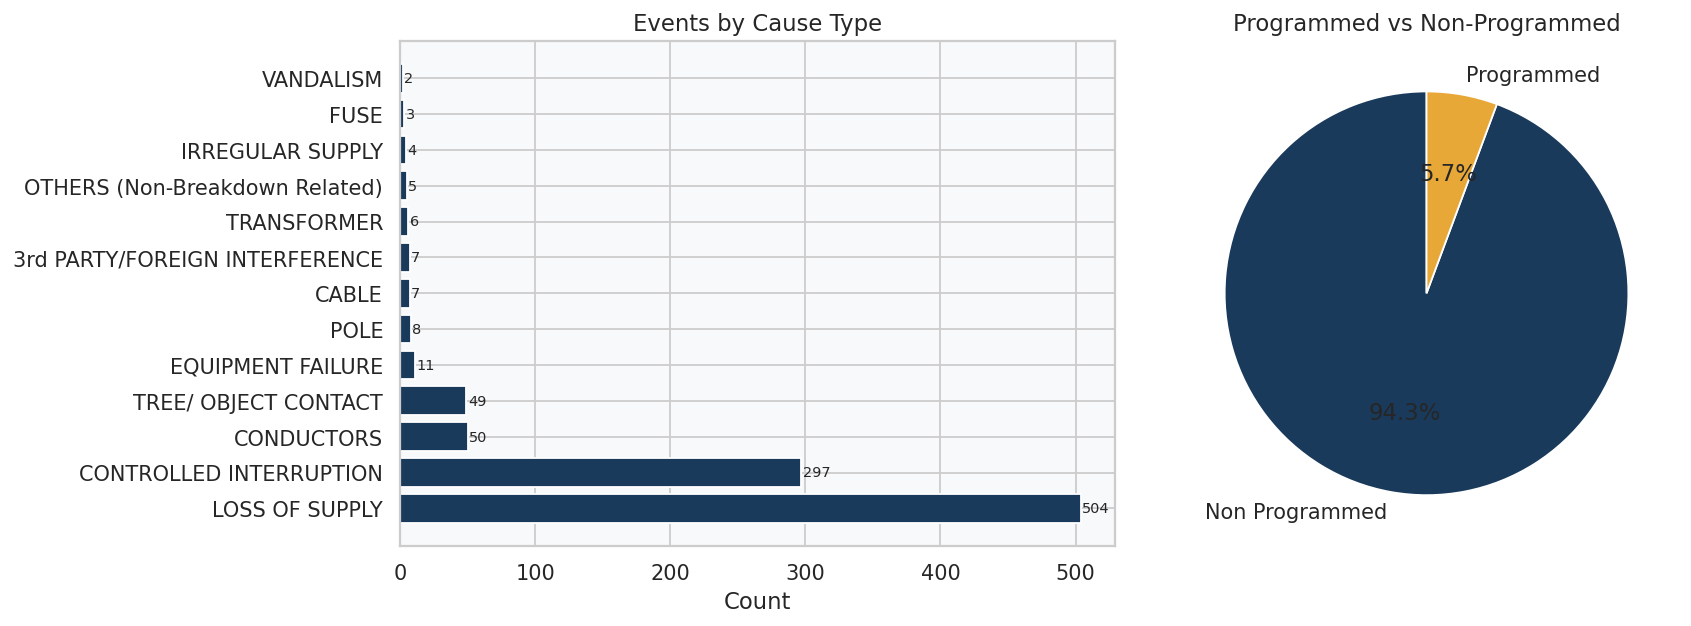

In [ ]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ct = inc_raw.CAUSE_TYPE.value_counts()
    axes[0].barh(ct.index, ct.values, color=PALETTE[0])
    axes[0].set_title("Events by Cause Type"); axes[0].set_xlabel("Count")
    for i, v in enumerate(ct.values):
        axes[0].text(v + 1, i, str(v), va="center", fontsize=8)

    it = inc_raw.INCIDENCE_TYPE.value_counts()
    axes[1].pie(it.values, labels=it.index, autopct="%1.1f%%",
                colors=[PALETTE[0], PALETTE[2]], startangle=90)
    axes[1].set_title("Programmed vs Non-Programmed")

    plt.tight_layout()
    plt.savefig(PATHS["figures"] / "02_cause_distribution.png", dpi=130)
    plt.show()


### 2.4 — Temporal Patterns

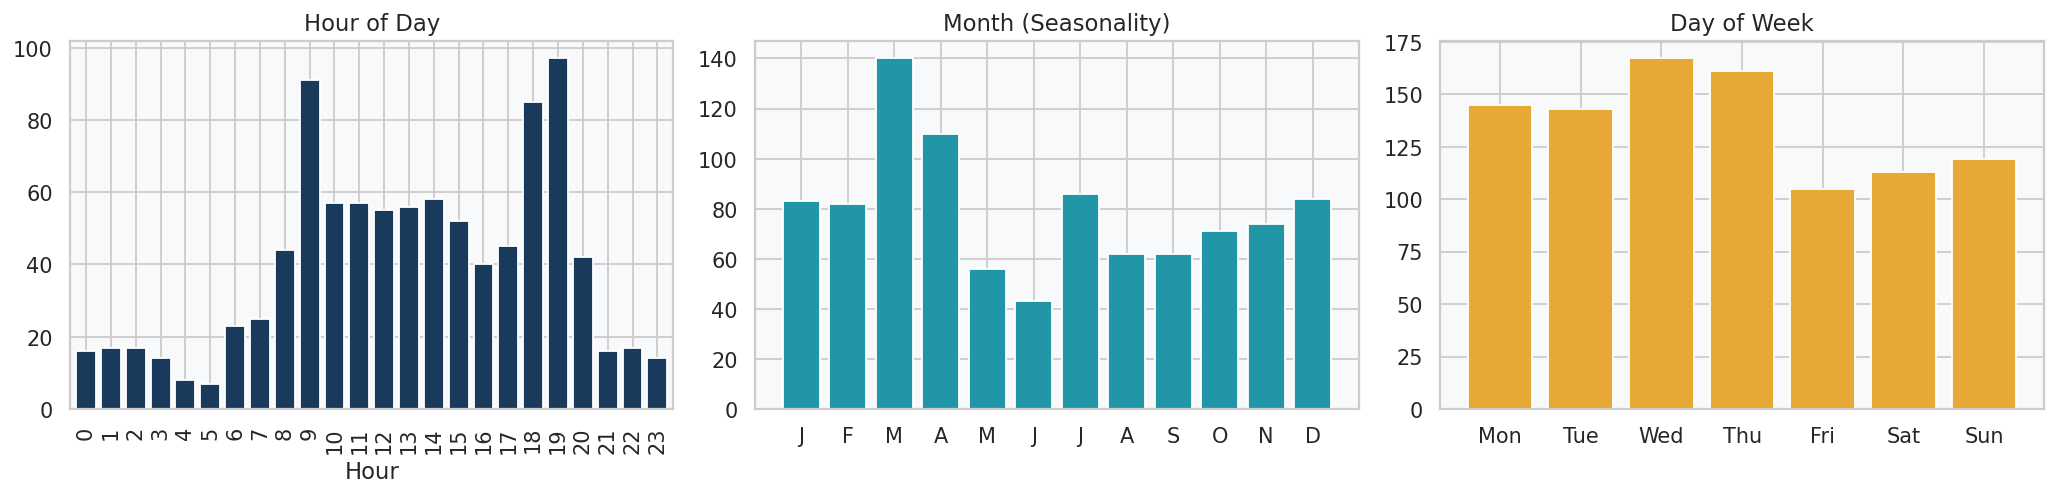

In [ ]:
    inc_raw["hour"]  = pd.to_datetime(inc_raw.DETECTION_DATE).dt.hour
    inc_raw["month"] = pd.to_datetime(inc_raw.DETECTION_DATE).dt.month
    inc_raw["dow"]   = pd.to_datetime(inc_raw.DETECTION_DATE).dt.dayofweek

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    inc_raw.hour.value_counts().sort_index().plot(
        kind="bar", ax=axes[0], color=PALETTE[0], width=0.8)
    axes[0].set_title("Hour of Day"); axes[0].set_xlabel("Hour")

    mc = inc_raw.month.value_counts().sort_index()
    axes[1].bar(mc.index, mc.values, color=PALETTE[1])
    axes[1].set_xticks(range(1,13))
    axes[1].set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
    axes[1].set_title("Month (Seasonality)")

    dc = inc_raw.dow.value_counts().sort_index()
    axes[2].bar(dc.index, dc.values, color=PALETTE[2])
    axes[2].set_xticks(range(7))
    axes[2].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
    axes[2].set_title("Day of Week")

    plt.tight_layout()
    plt.savefig(PATHS["figures"] / "02_temporal_patterns.png", dpi=130)
    plt.show()


### 2.5 — Weather Distributions

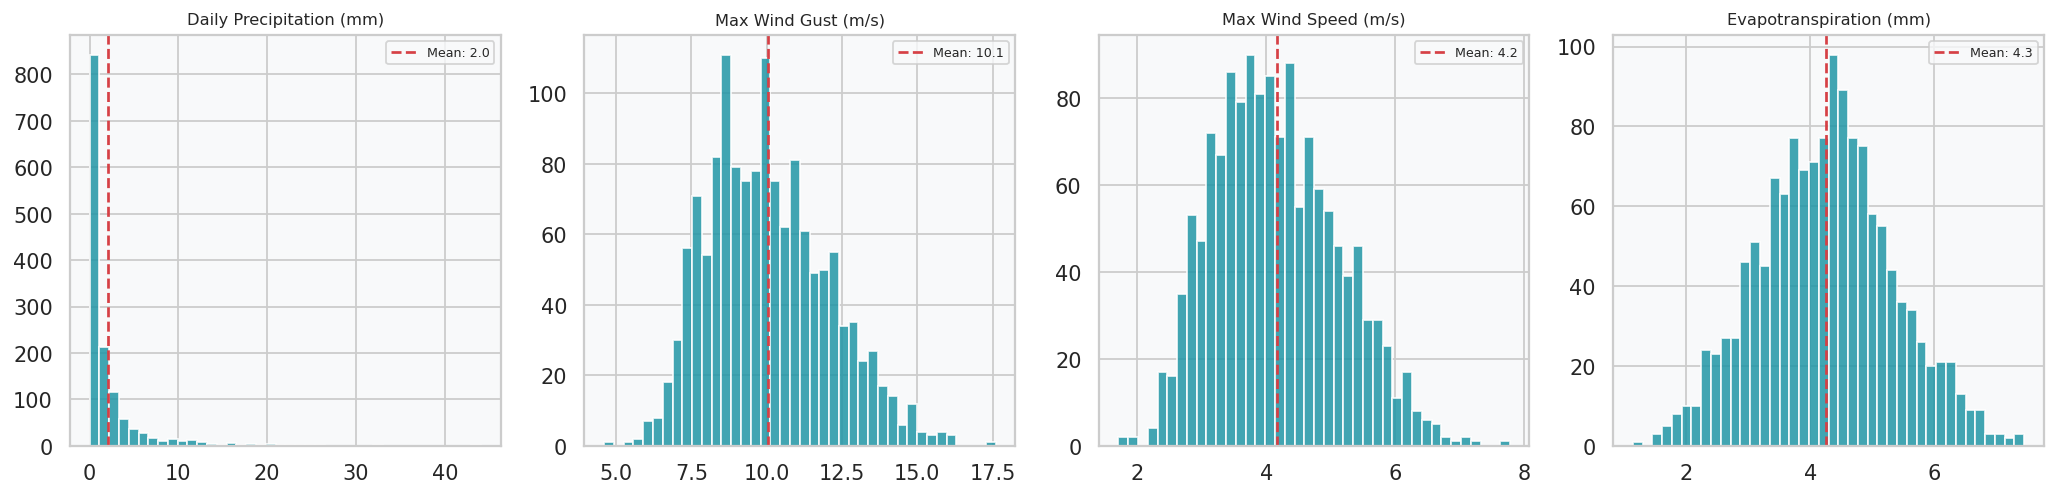

In [ ]:
    vars_labels = [
        ("precipitation_sum",          "Daily Precipitation (mm)"),
        ("wind_gusts_10m_max",          "Max Wind Gust (m/s)"),
        ("wind_speed_10m_max",          "Max Wind Speed (m/s)"),
        ("et0_fao_evapotranspiration",  "Evapotranspiration (mm)"),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, (var, label) in zip(axes, vars_labels):
        ax.hist(weather[var].dropna(), bins=40, color=PALETTE[1],
                edgecolor="white", alpha=0.85)
        ax.axvline(weather[var].mean(), color=PALETTE[3], linestyle="--",
                   linewidth=1.5, label=f"Mean: {weather[var].mean():.1f}")
        ax.set_title(label, fontsize=9); ax.legend(fontsize=7)

    plt.tight_layout()
    plt.savefig(PATHS["figures"] / "02_weather_distributions.png", dpi=130)
    plt.show()


### 2.6 — Interactive Feeder Network Map

In [ ]:
    fig = go.Figure()
    feeder_colours = {f: PALETTE[i] for i, f in enumerate(ACTIVE_FEEDERS)}

    # Feeder cable routes from DXF
    for feeder in ACTIVE_FEEDERS:
        fl = lines[lines.feeder_name == feeder]
        for _, row in fl.iterrows():
            fig.add_trace(go.Scattermapbox(
                lat=[row.lat_start, row.lat_end],
                lon=[row.lon_start, row.lon_end],
                mode="lines",
                line=dict(width=1.8, color=feeder_colours[feeder]),
                name=feeder.replace(" EX LANGATA",""),
                showlegend=False,
            ))

    # Primary substation
    ps = nodes[nodes.node_type == "primary_substation"].iloc[0]
    fig.add_trace(go.Scattermapbox(
        lat=[ps.lat], lon=[ps.lon], mode="markers+text",
        marker=dict(size=16, color="#d64045", symbol="star"),
        text=["Langata 66kV/11kV"], textposition="top right",
        name="Primary Substation",
    ))

    # Secondary substations
    for feeder in ACTIVE_FEEDERS:
        fn = nodes[(nodes.node_type == "secondary_substation") &
                   (nodes.feeder_name == feeder)]
        fig.add_trace(go.Scattermapbox(
            lat=fn.lat, lon=fn.lon, mode="markers",
            marker=dict(size=5, color=feeder_colours[feeder]),
            name=feeder.replace(" EX LANGATA",""),
            hovertemplate="%{text}<extra></extra>",
            text=fn.attributes.fillna(""),
        ))

    fig.update_layout(
        mapbox=dict(style="open-street-map",
                    center=dict(lat=-1.339, lon=36.757), zoom=12),
        height=560, margin=dict(l=0, r=0, t=35, b=0),
        title="Langata Substation — Feeder Network",
        legend=dict(x=0.01, y=0.99, bgcolor="rgba(255,255,255,0.85)"),
    )
    fig.show()
    fig.write_html(str(PATHS["figures"] / "02_feeder_network_map.html"))
    print("✅ Interactive map saved")


✅ Interactive map saved


### 2.7 — Financial & Reliability Summary

In [ ]:
    clean_inc = inc_raw[inc_raw.DURATION_HRS > 0].copy()

    summary = clean_inc.groupby("INSTALATION_1").agg(
        events           = ("INCIDENCE",        "count"),
        total_hours      = ("DURATION_HRS",      "sum"),
        avg_duration_hrs = ("DURATION_HRS",      "mean"),
        loss_mksh        = ("LOSS_MILLION_KSH",  "sum"),
        loss_gwhrs       = ("LOSS_GWHRS",        "sum"),
    ).round(3).sort_values("loss_mksh", ascending=False)

    display(summary)
    print(f"\nTotal financial loss : KES {clean_inc.LOSS_MILLION_KSH.sum():.2f} million")
    print(f"Total energy loss    : {clean_inc.LOSS_GWHRS.sum():.4f} GWh")
    print(f"Total outage hours   : {clean_inc.DURATION_HRS.sum():.1f} hrs")


,events,total_hours,avg_duration_hrs,loss_mksh,loss_gwhrs
INSTALATION_1,,,,,
SOWETO EX LANGATA,300,784.900,2.616,41.057,2.933
MAGADI EX LANGATA,152,437.683,2.879,17.244,1.232
NGEI EX LANGATA,99,218.100,2.203,8.779,0.627
HARDY EX LANGATA,121,368.183,3.043,8.215,0.587
NDALATI EX LANGATA,97,229.800,2.369,6.289,0.449
KUWINDA EX LANGATA,98,189.950,1.938,2.569,0.184
KAREN HOSPITAL EX LANGATA,65,192.833,2.967,1.693,0.121
OTIENDE EX LANGATA,8,26.967,3.371,0.046,0.003
ICOLO EX LANGATA,2,0.067,0.033,0.000,0.000



Total financial loss : KES 85.89 million
Total energy loss    : 6.1351 GWh
Total outage hours   : 2448.5 hrs


    ---
    ## 🔧 Section 3 — Data Preparation
    > Builds both training datasets. Outputs persist to Drive — run once.
    

### 3.1 — Clean Incidence Events

In [ ]:
    def clean_incidences(df):
        """
        Remove logging errors (duration ≤ 0), drop Icolo feeder (only 2 events),
        assign outage class from cause type, and extract the event date.
        """
        df = df[df.DURATION_HRS > 0].copy()
        df = df[df.INSTALATION_1 != "ICOLO EX LANGATA"].copy()
        df["outage_class"] = df.CAUSE_TYPE.map(CAUSE_CLASS_MAP).fillna(3).astype(int)
        df["date"]         = pd.to_datetime(df.DETECTION_DATE).dt.normalize()
        return df.reset_index(drop=True)

    inc = clean_incidences(inc_raw)
    print(f"Clean events : {len(inc):,}  (removed {len(inc_raw) - len(inc)} bad rows)")
    print(f"Date range   : {inc.date.min().date()} → {inc.date.max().date()}")
    print(f"\nClass distribution:")
    for cls, cnt in inc.outage_class.value_counts().sort_index().items():
        print(f"  Class {cls} ({LABELS_3.get(cls, cls):<26}) : {cnt:4d}  "
              f"{'█' * (cnt // 30)}")


Clean events : 940  (removed 13 bad rows)
Date range   : 2022-07-01 → 2026-04-29

Class distribution:
  Class 1 (Loss of Supply            ) :  497  ████████████████
  Class 2 (Controlled Interruption   ) :  295  █████████
  Class 3 (Physical Fault            ) :  148  ████


### 3.2 — Build Feeder-Day Grid (Stage 1 training data)

In [ ]:
    def build_feeder_day_grid(inc):
        """
        Create one row per feeder per calendar day (8 feeders × 1,399 days = 11,192 rows).
        Outage days carry aggregated event data. No-outage days are filled with zeros.
        The binary column `had_outage` is the Stage 1 target.
        """
        CLASS_PRIORITY = {3:3, 1:2, 2:1, 0:0}

        def dominant_class(series):
            """On days with multiple events, use the highest-priority class."""
            return max(series, key=lambda c: CLASS_PRIORITY[c])

        agg = inc.groupby(["INSTALATION_1","date"]).agg(
            outage_class          = ("outage_class",    dominant_class),
            n_outages             = ("outage_class",    "count"),
            total_duration_hrs    = ("DURATION_HRS",    "sum"),
            programmed_flag       = ("INCIDENCE_TYPE",  lambda x: int((x=="Programmed").any())),
            total_loss_gwhrs      = ("LOSS_GWHRS",      "sum"),
            total_loss_mksh       = ("LOSS_MILLION_KSH","sum"),
            saifi_numerator       = ("NUMERATOR_SAIFI", "sum"),
            saidi_numerator       = ("NUMERATOR_SAIDI", "sum"),
            cause_type_primary    = ("CAUSE_TYPE",      lambda x: x.mode()[0]),
            cause_subtype_primary = ("CAUSE_SUBTYPE",   lambda x: x.mode()[0]),
            cause_primary         = ("CAUSE",           lambda x: x.mode()[0]),
        ).reset_index().rename(columns={"INSTALATION_1":"feeder"})

        all_dates = pd.date_range(DATA_START, DATA_END, freq="D")
        grid = pd.DataFrame(
            pd.MultiIndex.from_product(
                [ACTIVE_FEEDERS, all_dates], names=["feeder","date"]
            ).tolist(),
            columns=["feeder","date"],
        )
        grid = grid.merge(agg, on=["feeder","date"], how="left")

        for col in ["outage_class","n_outages","programmed_flag","saifi_numerator"]:
            grid[col] = grid[col].fillna(0).astype(int)
        for col in ["total_duration_hrs","total_loss_gwhrs","total_loss_mksh","saidi_numerator"]:
            grid[col] = grid[col].fillna(0.0)
        for col in ["cause_type_primary","cause_subtype_primary","cause_primary"]:
            grid[col] = grid[col].fillna("")

        grid["had_outage"] = (grid.outage_class > 0).astype(int)
        return grid

    grid = build_feeder_day_grid(inc)
    n_out = grid.had_outage.sum()
    n_tot = len(grid)
    print(f"Grid shape      : {n_tot:,} rows × {grid.shape[1]} columns")
    print(f"Outage days     : {n_out:,}  |  No-outage days : {n_tot - n_out:,}")
    print(f"Imbalance ratio : 1 : {(n_tot - n_out) // n_out}")


Grid shape      : 11,192 rows × 14 columns
Outage days     : 825  |  No-outage days : 10,367
Imbalance ratio : 1 : 12


### 3.3 — Topology, Temporal, Static & Rolling Features

In [ ]:
    def add_topology(df, topo):
        """Merge per-feeder network statistics from the DXF parser."""
        return df.merge(topo.rename(columns={"feeder_name":"feeder"}),
                        on="feeder", how="left")

    def add_temporal_features(df, date_col="date"):
        """
        Calendar features with cyclical encoding so Dec/Jan and Mon/Sun
        are treated as adjacent — important for tree-based models.
        """
        df = df.copy()
        d  = pd.to_datetime(df[date_col])
        df["year"]        = d.dt.year
        df["month"]       = d.dt.month
        df["day_of_week"] = d.dt.dayofweek
        df["day_of_year"] = d.dt.dayofyear
        df["is_weekend"]  = (d.dt.dayofweek >= 5).astype(int)
        df["season"]      = d.dt.month.map(SEASON_MAP)
        df["month_sin"]   = np.sin(2*np.pi*df.month/12)
        df["month_cos"]   = np.cos(2*np.pi*df.month/12)
        df["dow_sin"]     = np.sin(2*np.pi*df.day_of_week/7)
        df["dow_cos"]     = np.cos(2*np.pi*df.day_of_week/7)
        dummies = pd.get_dummies(df.season, prefix="season").astype(int)
        for s in ["long_dry","long_rains","short_dry","short_rains"]:
            if f"season_{s}" not in dummies.columns:
                dummies[f"season_{s}"] = 0
        return pd.concat([df.drop(columns="season"), dummies], axis=1)

    def add_feeder_static(df):
        """Attach max demand, customer count, and numeric feeder ID."""
        df = df.copy()
        df["max_demand_kva"]     = df.feeder.map({k:v["max_demand_kva"]     for k,v in FEEDER_STATIC.items()})
        df["affected_customers"] = df.feeder.map({k:v["affected_customers"] for k,v in FEEDER_STATIC.items()})
        feeder_codes = {f:i for i,f in enumerate(sorted(df.feeder.unique()))}
        df["feeder_id"] = df.feeder.map(feeder_codes)
        return df, feeder_codes

    def add_rolling_history(df):
        """
        Per-feeder rolling statistics using past data only.
        shift(1) ensures today's outage never predicts itself.
        """
        df = df.sort_values(["feeder","date"]).reset_index(drop=True)
        segments = []
        for feeder, grp in df.groupby("feeder", sort=False):
            grp       = grp.copy().reset_index(drop=True)
            past_flag = grp.had_outage.shift(1, fill_value=0)
            past_hrs  = grp.total_duration_hrs.shift(1, fill_value=0.0)
            grp["outages_last_7d"]      = past_flag.rolling(7,  min_periods=1).sum().astype(int)
            grp["outages_last_30d"]     = past_flag.rolling(30, min_periods=1).sum().astype(int)
            grp["duration_last_7d_hrs"] = past_hrs.rolling(7,   min_periods=1).sum().round(4)
            days_since, clean_streak, days_ago, clean = [], [], None, 0
            for had in past_flag:
                days_since.append(days_ago if days_ago is not None else 30)
                clean_streak.append(clean)
                if had:
                    days_ago, clean = 1, 0
                else:
                    days_ago = (days_ago + 1) if days_ago is not None else None
                    clean   += 1
            grp["days_since_last_outage"] = days_since
            grp["consecutive_clean_days"] = clean_streak
            segments.append(grp)
        return pd.concat(segments, ignore_index=True)

    # Apply all transformations
    grid = add_topology(grid, topology)
    grid = add_temporal_features(grid)
    grid, FEEDER_CODES = add_feeder_static(grid)
    grid = add_rolling_history(grid)
    print("✅ Topology, temporal, static, and rolling features added")


✅ Topology, temporal, static, and rolling features added


### 3.4 — Weather, Holiday & Interaction Features

In [ ]:
    def add_weather_holidays(df, wx, hol):
        """Join daily weather and holiday features by date."""
        wx  = wx.copy()
        hol = hol.drop(columns=["holiday_name"], errors="ignore").copy()
        wx["heavy_rain_day"] = (wx.precipitation_sum  > 10).astype(int)
        wx["high_wind_day"]  = (wx.wind_gusts_10m_max > 10).astype(int)
        df["date"] = pd.to_datetime(df["date"])
        wx["date"] = pd.to_datetime(wx["date"])
        hol["date"]= pd.to_datetime(hol["date"])
        df = df.merge(wx,  on="date", how="left")
        df = df.merge(hol, on="date", how="left")
        df["is_public_holiday"]    = df.is_public_holiday.fillna(0).astype(int)
        df["is_long_weekend"]      = df.is_long_weekend.fillna(0).astype(int)
        df["days_to_next_holiday"] = df.days_to_next_holiday.fillna(30)
        df["days_since_holiday"]   = df.days_since_holiday.fillna(30)
        return df

    def add_interaction_features(df):
        """
        Domain-driven compound features that capture risk better than
        individual signals in isolation.

        feeder_outage_rate     — feeder's historical daily failure probability
        storm_index            — precipitation × wind gust (compound storm severity)
        rain_season_interaction — rainfall amplified during long-rains season
        demand_risk_score      — high-demand feeders that also fail often
        overdue_pressure       — quiet feeder with a busy recent history
        length_x_outage_rate   — long lines on unreliable feeders
        """
        df = df.copy()
        rate = df.groupby("feeder")["had_outage"].transform("mean")
        df["feeder_outage_rate"]      = rate.round(6)
        df["storm_index"]             = df.precipitation_sum * df.wind_gusts_10m_max
        df["rain_season_interaction"] = df.season_long_rains * df.precipitation_sum
        df["demand_risk_score"]       = df.max_demand_kva    * df.feeder_outage_rate
        df["overdue_pressure"]        = df.days_since_last_outage * df.outages_last_30d
        df["length_x_outage_rate"]    = df.total_length_km   * df.feeder_outage_rate
        return df

    grid = add_weather_holidays(grid, weather, holidays)
    grid = add_interaction_features(grid)
    print("✅ Weather, holiday, and interaction features added")
    print(f"   Weather nulls : {grid[['precipitation_sum','wind_gusts_10m_max']].isnull().sum().sum()}")


✅ Weather, holiday, and interaction features added
   Weather nulls : 0


### 3.5 — Define Stage 1 Feature Set

In [ ]:
    # Excluded from Stage 1 modelling:
    #   identifiers, targets, dashboard-only columns (financial, reliability),
    #   n_segments (collinear with total_length_km)
    EXCLUDE_S1 = [
        "feeder","date","had_outage","outage_class",
        "n_outages","total_duration_hrs","programmed_flag",
        "cause_type_primary","cause_subtype_primary","cause_primary",
        "total_loss_gwhrs","total_loss_mksh","saifi_numerator","saidi_numerator",
        "n_segments",
    ]
    FEATURES_S1 = [
        c for c in grid.columns
        if c not in EXCLUDE_S1 and grid[c].dtype != object
    ]
    TARGET_S1 = "had_outage"

    print(f"Stage 1 feature set ({len(FEATURES_S1)} features):")
    for f in FEATURES_S1:
        print(f"  {f}")


Stage 1 feature set (42 features):
  total_length_km
  n_secondary_subs
  n_switches
  avg_segment_m
  bbox_area_km2
  year
  month
  day_of_week
  day_of_year
  is_weekend
  month_sin
  month_cos
  dow_sin
  dow_cos
  season_long_dry
  season_long_rains
  season_short_dry
  season_short_rains
  max_demand_kva
  affected_customers
  feeder_id
  outages_last_7d
  outages_last_30d
  duration_last_7d_hrs
  days_since_last_outage
  consecutive_clean_days
  precipitation_sum
  wind_speed_10m_max
  wind_gusts_10m_max
  et0_fao_evapotranspiration
  heavy_rain_day
  high_wind_day
  is_public_holiday
  is_long_weekend
  days_to_next_holiday
  days_since_holiday
  feeder_outage_rate
  storm_index
  rain_season_interaction
  demand_risk_score
  overdue_pressure
  length_x_outage_rate


### 3.6 — Build Event Dataset (Stage 2 training data)

In [ ]:
    def build_event_dataset(inc, wx, hol, topo, feeder_codes):
        """
        Build the event-level dataset for Stage 2 fault classification.
        Unit: one row = one real outage event (940 records).

        Key differences from the feeder-day grid:
          - Hour of day is included (fault type correlates with demand cycle)
          - Rolling features count past EVENTS, not past days
          - Post-event columns (duration, loss, SAIFI) are excluded to prevent leakage
        """
        df = inc.copy()

        # Weather and holidays joined by date
        wx2  = wx.drop(columns=["rain_sum"], errors="ignore").copy()
        hol2 = hol.drop(columns=["holiday_name"], errors="ignore").copy()
        wx2["heavy_rain_day"]  = (wx2.precipitation_sum  > 10).astype(int)
        wx2["high_wind_day"]   = (wx2.wind_gusts_10m_max > 10).astype(int)
        df["date"] = pd.to_datetime(df.DETECTION_DATE).dt.normalize()
        for frame in [wx2, hol2]:
            frame["date"] = pd.to_datetime(frame["date"])
        df = df.merge(wx2,  on="date", how="left")
        df = df.merge(hol2, on="date", how="left")

        # Temporal features including hour
        d = pd.to_datetime(df.DETECTION_DATE)
        df["hour"]        = d.dt.hour
        df["month"]       = d.dt.month
        df["day_of_week"] = d.dt.dayofweek
        df["day_of_year"] = d.dt.dayofyear
        df["year"]        = d.dt.year
        df["is_weekend"]  = (d.dt.dayofweek >= 5).astype(int)
        df["season"]      = d.dt.month.map(SEASON_MAP)
        df["month_sin"]   = np.sin(2*np.pi*df.month/12)
        df["month_cos"]   = np.cos(2*np.pi*df.month/12)
        df["dow_sin"]     = np.sin(2*np.pi*df.day_of_week/7)
        df["dow_cos"]     = np.cos(2*np.pi*df.day_of_week/7)
        df["hour_sin"]    = np.sin(2*np.pi*df.hour/24)
        df["hour_cos"]    = np.cos(2*np.pi*df.hour/24)
        dummies = pd.get_dummies(df.season, prefix="season").astype(int)
        for s in ["long_dry","long_rains","short_dry","short_rains"]:
            if f"season_{s}" not in dummies.columns:
                dummies[f"season_{s}"] = 0
        df = pd.concat([df.drop(columns="season"), dummies], axis=1)

        # Static feeder features
        df["max_demand_kva"]     = df.INSTALATION_1.map({k:v["max_demand_kva"]     for k,v in FEEDER_STATIC.items()})
        df["affected_customers"] = df.INSTALATION_1.map({k:v["affected_customers"] for k,v in FEEDER_STATIC.items()})
        df["feeder_id"]          = df.INSTALATION_1.map(feeder_codes)

        # Topology features
        topo2 = topo.rename(columns={"feeder_name":"INSTALATION_1"})
        df = df.merge(
            topo2[["INSTALATION_1","total_length_km","n_secondary_subs",
                   "n_switches","avg_segment_m","bbox_area_km2"]],
            on="INSTALATION_1", how="left",
        )

        # Rolling event history — past events per feeder only (no leakage)
        df = df.sort_values(["INSTALATION_1","DETECTION_DATE"]).reset_index(drop=True)
        segments = []
        for feeder, grp in df.groupby("INSTALATION_1", sort=False):
            grp = grp.copy().reset_index(drop=True)
            e7, e30, dsl = [], [], []
            for i in range(len(grp)):
                t    = grp.loc[i,"DETECTION_DATE"]
                past = (grp.loc[:i-1,"DETECTION_DATE"]
                        if i > 0 else pd.Series([], dtype="datetime64[ns]"))
                e7.append(int((past >= t - pd.Timedelta(days=7)).sum()))
                e30.append(int((past >= t - pd.Timedelta(days=30)).sum()))
                dsl.append(
                    float((t - grp.loc[i-1,"DETECTION_DATE"]).days) if i > 0 else 30.0
                )
            grp["events_last_7d"]  = e7
            grp["events_last_30d"] = e30
            grp["days_since_last"] = dsl
            segments.append(grp)
        df = pd.concat(segments, ignore_index=True)

        # Interaction features
        n = len(df)
        df["feeder_event_share"]      = df.groupby("INSTALATION_1")["outage_class"].transform(
                                           lambda x: len(x) / n)
        df["storm_index"]             = df.precipitation_sum * df.wind_gusts_10m_max
        df["rain_season_interaction"] = df.season_long_rains * df.precipitation_sum
        df["demand_load_factor"]      = df.max_demand_kva   * df.events_last_30d

        # Fill remaining nulls
        df["is_public_holiday"]    = df.is_public_holiday.fillna(0).astype(int)
        df["is_long_weekend"]      = df.is_long_weekend.fillna(0).astype(int)
        df["days_to_next_holiday"] = df.days_to_next_holiday.fillna(30)
        df["days_since_holiday"]   = df.days_since_holiday.fillna(30)

        return df

    events = build_event_dataset(inc, weather, holidays, topology, FEEDER_CODES)
    print(f"Event dataset : {len(events):,} rows × {events.shape[1]} columns")


Event dataset : 940 rows × 70 columns


### 3.7 — Define Stage 2 Feature Set

In [ ]:
    # Post-event columns are excluded — measured AFTER the outage resolves.
    # Including them would let the model cheat during training.
    LEAKAGE_COLS = [
        "DURATION_HRS","LOSS_GWHRS","LOSS_MILLION_KSH",
        "NUMERATOR_SAIFI","NUMERATOR_SAIDI","SR_DURATION",
    ]
    ID_COLS_S2 = [
        "INCIDENCE","DESC_INCIDENCIA","DETECTION_DATE","RESOLUTION_DATE",
        "INSTALATION_1","CAUSE_TYPE","CAUSE_SUBTYPE","CAUSE","INCIDENCE_TYPE",
        "CURRENT_STATUS","REGION","COUNTY","INSTALATION","PARENT",
        "INSTALATION_TYPE","FBBU_NAME","MONTH_YEAR","FY",
        "MAX_DEMAND","AFFECTED_CUSTOMERS","date",
    ]
    FEATURES_S2 = [
        c for c in events.columns
        if c not in ID_COLS_S2 + LEAKAGE_COLS + ["outage_class"]
        and events[c].dtype != object
    ]
    TARGET_S2 = "outage_class"

    print(f"Stage 2 feature set ({len(FEATURES_S2)} features):")
    for f in FEATURES_S2:
        print(f"  {f}")


Stage 2 feature set (42 features):
  hour
  month
  dow
  precipitation_sum
  wind_speed_10m_max
  wind_gusts_10m_max
  et0_fao_evapotranspiration
  heavy_rain_day
  high_wind_day
  is_public_holiday
  is_long_weekend
  days_to_next_holiday
  days_since_holiday
  day_of_week
  day_of_year
  year
  is_weekend
  month_sin
  month_cos
  dow_sin
  dow_cos
  hour_sin
  hour_cos
  season_long_dry
  season_long_rains
  season_short_dry
  season_short_rains
  max_demand_kva
  affected_customers
  feeder_id
  total_length_km
  n_secondary_subs
  n_switches
  avg_segment_m
  bbox_area_km2
  events_last_7d
  events_last_30d
  days_since_last
  feeder_event_share
  storm_index
  rain_season_interaction
  demand_load_factor


### 3.8 — Validate & Save Both Datasets

In [ ]:
    # Null check — any nulls in features would silently corrupt model training
    print("Null check:")
    for name, df, features, target in [
        ("feeder_day_frame", grid,   FEATURES_S1, TARGET_S1),
        ("events_features",  events, FEATURES_S2, TARGET_S2),
    ]:
        nulls = df[features + [target]].isnull().sum()
        bad   = nulls[nulls > 0]
        print(f"  {name:<22}: {'✅ clean' if len(bad)==0 else f'⚠️ {bad.to_dict()}'}")

    grid.to_csv(PATHS["processed"] / "feeder_day_frame.csv",  index=False)
    events.to_csv(PATHS["processed"] / "events_features.csv", index=False)

    print(f"\n✅ feeder_day_frame.csv  ({len(grid):,} rows × {grid.shape[1]} cols)")
    print(f"✅ events_features.csv   ({len(events):,} rows × {events.shape[1]} cols)")


Null check:
  feeder_day_frame      : ✅ clean
  events_features       : ✅ clean

✅ feeder_day_frame.csv  (11,192 rows × 57 cols)
✅ events_features.csv   (940 rows × 70 cols)


---
## 📈 Section 4A — Time Series Models (SARIMA + Prophet)
> Captures autocorrelation, Kenya's seasonal rainfall patterns, and long-term
> trend in daily outage occurrence per feeder.


### 4A.1 — Prepare Daily Binary Series per Feeder

In [ ]:
all_dates = pd.date_range(DATA_START, DATA_END, freq="D")

# One binary series per feeder: 1 = outage occurred, 0 = no outage
feeder_series = {
    feeder: (
        grid[grid.feeder == feeder]
            .sort_values("date")
            .set_index("date")["had_outage"]
            .reindex(all_dates, fill_value=0)
    )
    for feeder in ACTIVE_FEEDERS
}

split_ts = pd.Timestamp(SPLIT_DATE)
print("Binary series summary (train / test):")
for feeder, ts in feeder_series.items():
    tr = ts[ts.index <  split_ts]
    te = ts[ts.index >= split_ts]
    print(f"  {feeder.replace(' EX LANGATA',''):<25} "
          f"train={len(tr)} d ({tr.sum()} outages)  "
          f"test={len(te)} d ({te.sum()} outages)")


Binary series summary (train / test):
  HARDY                     train=1096 d (82 outages)  test=303 d (22 outages)
  KAREN HOSPITAL            train=1096 d (53 outages)  test=303 d (9 outages)
  KUWINDA                   train=1096 d (73 outages)  test=303 d (16 outages)
  MAGADI                    train=1096 d (103 outages)  test=303 d (27 outages)
  NDALATI                   train=1096 d (80 outages)  test=303 d (11 outages)
  NGEI                      train=1096 d (61 outages)  test=303 d (23 outages)
  OTIENDE                   train=1096 d (4 outages)  test=303 d (4 outages)
  SOWETO                    train=1096 d (192 outages)  test=303 d (65 outages)


### 4A.2 — Fit SARIMA Models

In [ ]:
def fit_sarima(series, feeder):
    """
    Fit SARIMA(1,0,1)(1,1,0,7) to a daily binary outage series.
    Weekly seasonality (s=7) captures the Monday–Sunday demand cycle.
    Only applied to SARIMA_FEEDERS (feeders with enough non-zero months).
    """
    train = series[series.index < pd.Timestamp(SPLIT_DATE)]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = SARIMAX(
            train,
            order=(1, 0, 1),
            seasonal_order=(1, 1, 0, 7),
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False)
    return model

sarima_models = {}
print("Fitting SARIMA models:")
for feeder in SARIMA_FEEDERS:
    sarima_models[feeder] = fit_sarima(feeder_series[feeder], feeder)
    print(f"  ✅ {feeder.replace(' EX LANGATA',''):<25}  AIC = {sarima_models[feeder].aic:.1f}")

print(f"\n{len(sarima_models)}/8 feeders fitted  "
      f"(KAREN HOSPITAL and OTIENDE skipped — sparse monthly data → Prophet only)")


Fitting SARIMA models:
  ✅ HARDY                      AIC = 636.9
  ✅ KUWINDA                    AIC = 518.6
  ✅ MAGADI                     AIC = 792.2
  ✅ NDALATI                    AIC = 603.5
  ✅ NGEI                       AIC = 328.6
  ✅ SOWETO                     AIC = 1406.4

6/8 feeders fitted  (KAREN HOSPITAL and OTIENDE skipped — sparse monthly data → Prophet only)


### 4A.3 — Fit Prophet Models

In [ ]:
def fit_prophet(series, feeder):
    """
    Fit Prophet to the daily binary outage series.
    Handles Kenya's dual rainy seasons, public holidays,
    sparse feeders (Karen Hospital, Otiende), and trend shifts.
    """
    train = series[series.index < pd.Timestamp(SPLIT_DATE)]

    hol_df = (holidays[holidays.is_public_holiday == 1][["date"]]
              .rename(columns={"date":"ds"})
              .assign(holiday="Kenya_Public_Holiday",
                      lower_window=0, upper_window=1))

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        holidays=hol_df,
        seasonality_mode="multiplicative",
        changepoint_prior_scale=0.05,
        holidays_prior_scale=5.0,
        interval_width=0.80,
    )
    m.add_seasonality(name="kenya_long_rains", period=365.25/2, fourier_order=3)

    prophet_df = pd.DataFrame({"ds": train.index, "y": train.values})
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        m.fit(prophet_df)
    return m

prophet_models = {}
print("Fitting Prophet models:")
for feeder in ACTIVE_FEEDERS:
    prophet_models[feeder] = fit_prophet(feeder_series[feeder], feeder)
    print(f"  ✅ {feeder.replace(' EX LANGATA',''):<25}")

print(f"\nAll {len(prophet_models)} feeders fitted")


Fitting Prophet models:
  ✅ HARDY                    
  ✅ KAREN HOSPITAL           
  ✅ KUWINDA                  
  ✅ MAGADI                   
  ✅ NDALATI                  
  ✅ NGEI                     
  ✅ OTIENDE                  
  ✅ SOWETO                   

All 8 feeders fitted


### 4A.4 — Generate TS Probability Forecasts & Evaluate

In [ ]:
def generate_ts_probabilities(sarima_models, prophet_models, all_dates):
    """
    Generate outage probability estimates from all time series models
    across the full date range. Output is normalised to [0, 1].
    SARIMA covers the test period only; Prophet covers all dates.
    """
    rows  = []
    split = pd.Timestamp(SPLIT_DATE)
    test_dates = all_dates[all_dates >= split]

    for feeder in ACTIVE_FEEDERS:
        # Prophet forecast over all dates
        m      = prophet_models[feeder]
        future = pd.DataFrame({"ds": all_dates})
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fc_p = m.predict(future)
        p_raw   = fc_p.set_index("ds")["yhat"].reindex(all_dates).values
        p_probs = np.clip(p_raw, 0, None)
        if p_probs.max() > 0:
            p_probs /= p_probs.max()

        # SARIMA forecast over test period
        if feeder in sarima_models:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                s_raw = sarima_models[feeder].get_forecast(
                    steps=len(test_dates)).predicted_mean.values
            s_probs = np.clip(s_raw, 0, None)
            s_probs = s_probs / (s_probs.max() + 1e-9)
        else:
            s_probs = None

        for i, date in enumerate(all_dates):
            sp = (float(s_probs[i - len(all_dates) + len(s_probs)])
                  if s_probs is not None and date >= split else np.nan)
            pp = float(p_probs[i])
            cp = (sp + pp) / 2 if not np.isnan(sp) else pp
            rows.append({
                "feeder":           feeder,
                "date":             date,
                "ts_prob_sarima":   sp,
                "ts_prob_prophet":  round(pp, 6),
                "ts_prob_combined": round(cp, 6),
            })

    return pd.DataFrame(rows)

print("Generating time series forecasts...")
ts_probs_df = generate_ts_probabilities(sarima_models, prophet_models, all_dates)

# Evaluate on test period
test_ts = (ts_probs_df[ts_probs_df.date >= pd.Timestamp(SPLIT_DATE)]
           .merge(grid[["feeder","date","had_outage"]], on=["feeder","date"]))

print("\nTime Series AUC on test period:")
print(f"{'Feeder':<28} {'Prophet':>9} {'SARIMA':>9} {'Combined':>10}")
print("─" * 62)
for feeder in ACTIVE_FEEDERS:
    sub = test_ts[test_ts.feeder == feeder].dropna(subset=["had_outage"])
    if sub.had_outage.sum() < 2: continue
    try:
        p_auc = roc_auc_score(sub.had_outage, sub.ts_prob_prophet)
        c_auc = roc_auc_score(sub.had_outage, sub.ts_prob_combined)
        s_str = (f"{roc_auc_score(sub.had_outage, sub.ts_prob_sarima.fillna(sub.ts_prob_prophet)):>9.4f}"
                 if feeder in sarima_models else "      N/A")
        print(f"  {feeder.replace(' EX LANGATA',''):<26} "
              f"{p_auc:>9.4f} {s_str:>9} {c_auc:>10.4f}")
    except Exception as e:
        print(f"  {feeder:<26} Error: {e}")


Generating time series forecasts...

Time Series AUC on test period:
Feeder                         Prophet    SARIMA   Combined
──────────────────────────────────────────────────────────────
  HARDY                         0.5312    0.4746     0.4812
  KAREN HOSPITAL                0.4025       N/A     0.4025
  KUWINDA                       0.5575    0.6000     0.5564
  MAGADI                        0.5373    0.5000     0.5373
  NDALATI                       0.5269    0.5635     0.5820
  NGEI                          0.5166    0.5370     0.5216
  OTIENDE                       0.3992       N/A     0.3992
  SOWETO                        0.4854    0.5000     0.4841


---
## 🤖 Section 4B — Binary ML Classifier (Stage 1)
> XGBoost + Random Forest on the feeder-day grid (11,192 rows).


### 4B.1 — Load Data & Train / Test Split

In [ ]:
# Load from Drive — re-running from this section skips Section 3
grid_df = pd.read_csv(
    PATHS["processed"] / "feeder_day_frame.csv", parse_dates=["date"]
)

# Re-derive interaction features (computed at runtime, not stored in CSV)
outage_rate = grid_df.groupby("feeder")["had_outage"].transform("mean")
grid_df["feeder_outage_rate"]      = outage_rate.round(6)
grid_df["storm_index"]             = grid_df.precipitation_sum * grid_df.wind_gusts_10m_max
grid_df["rain_season_interaction"] = grid_df.season_long_rains  * grid_df.precipitation_sum
grid_df["demand_risk_score"]       = grid_df.max_demand_kva     * grid_df.feeder_outage_rate
grid_df["overdue_pressure"]        = grid_df.days_since_last_outage * grid_df.outages_last_30d
grid_df["length_x_outage_rate"]    = grid_df.total_length_km    * grid_df.feeder_outage_rate

EXCLUDE_S1 = [
    "feeder","date","had_outage","outage_class",
    "n_outages","total_duration_hrs","programmed_flag",
    "cause_type_primary","cause_subtype_primary","cause_primary",
    "total_loss_gwhrs","total_loss_mksh","saifi_numerator","saidi_numerator",
    "n_segments",
]
FEATURES_S1 = [
    c for c in grid_df.columns
    if c not in EXCLUDE_S1 and grid_df[c].dtype != object
]
TARGET_S1 = "had_outage"

train_ml = grid_df[grid_df.date <  SPLIT_DATE]
test_ml  = grid_df[grid_df.date >= SPLIT_DATE]
X_train_s1, y_train_s1 = train_ml[FEATURES_S1], train_ml[TARGET_S1]
X_test_s1,  y_test_s1  = test_ml[FEATURES_S1],  test_ml[TARGET_S1]

print(f"Train : {len(train_ml):,} rows  ({y_train_s1.sum()} outage days)")
print(f"Test  : {len(test_ml):,}  rows  ({y_test_s1.sum()} outage days)")
print(f"Features : {len(FEATURES_S1)}")


Train : 8,768 rows  (648 outage days)
Test  : 2,424  rows  (177 outage days)
Features : 42


### 4B.2 — Class Weights (1:12.6 imbalance)

In [ ]:
# Inverse-frequency weighting — no synthetic samples needed at 1:12.6 ratio
counts_s1       = Counter(y_train_s1)
n_total         = len(y_train_s1)
CLASS_WEIGHTS_S1 = {cls: n_total / (2 * cnt) for cls, cnt in counts_s1.items()}

print(f"Class 0 weight : {CLASS_WEIGHTS_S1[0]:.4f}")
print(f"Class 1 weight : {CLASS_WEIGHTS_S1[1]:.4f}  "
      f"(Class 1 penalised {CLASS_WEIGHTS_S1[1]/CLASS_WEIGHTS_S1[0]:.1f}× more)")


Class 0 weight : 0.5399
Class 1 weight : 6.7654  (Class 1 penalised 12.5× more)


### 4B.3 — XGBoost Baseline

In [ ]:
xgb_s1 = xgb.XGBClassifier(
    objective         = "binary:logistic",
    n_estimators      = 400,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = CLASS_WEIGHTS_S1[1] / CLASS_WEIGHTS_S1[0],
    eval_metric       = "auc",
    use_label_encoder = False,
    random_state      = RANDOM_STATE,
    n_jobs            = -1,
)
xgb_s1.fit(X_train_s1, y_train_s1,
           eval_set=[(X_test_s1, y_test_s1)], verbose=False)

y_prob_xgb_s1 = xgb_s1.predict_proba(X_test_s1)[:, 1]
y_pred_xgb_s1 = (y_prob_xgb_s1 >= OUTAGE_THRESHOLD).astype(int)

print(f"XGBoost Baseline — ROC-AUC: {roc_auc_score(y_test_s1, y_prob_xgb_s1):.4f}")
print(classification_report(y_test_s1, y_pred_xgb_s1,
      target_names=["No Outage","Outage"], digits=4))


XGBoost Baseline — ROC-AUC: 0.6146
              precision    recall  f1-score   support

   No Outage     0.9387    0.7833    0.8540      2247
      Outage     0.1129    0.3503    0.1708       177

    accuracy                         0.7517      2424
   macro avg     0.5258    0.5668    0.5124      2424
weighted avg     0.8784    0.7517    0.8041      2424



### 4B.4 — Random Forest Baseline

In [ ]:
rf_s1 = RandomForestClassifier(
    n_estimators     = 400,
    max_depth        = None,
    min_samples_leaf = 2,
    max_features     = "sqrt",
    class_weight     = "balanced_subsample",
    random_state     = RANDOM_STATE,
    n_jobs           = -1,
)
rf_s1.fit(X_train_s1, y_train_s1)

y_prob_rf_s1 = rf_s1.predict_proba(X_test_s1)[:, 1]
y_pred_rf_s1 = (y_prob_rf_s1 >= OUTAGE_THRESHOLD).astype(int)

print(f"Random Forest Baseline — ROC-AUC: {roc_auc_score(y_test_s1, y_prob_rf_s1):.4f}")
print(classification_report(y_test_s1, y_pred_rf_s1,
      target_names=["No Outage","Outage"], digits=4))


Random Forest Baseline — ROC-AUC: 0.6525
              precision    recall  f1-score   support

   No Outage     0.9329    0.9470    0.9399      2247
      Outage     0.1678    0.1356    0.1500       177

    accuracy                         0.8878      2424
   macro avg     0.5504    0.5413    0.5450      2424
weighted avg     0.8771    0.8878    0.8822      2424



### 4B.5 — Optuna Hyperparameter Tuning

In [ ]:
def objective_s1(trial):
    """Maximise ROC-AUC via 5-fold stratified CV on training data."""
    params = {
        "objective":         "binary:logistic",
        "n_estimators":      trial.suggest_int("n_estimators", 200, 700),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "gamma":             trial.suggest_float("gamma", 0, 5),
        "reg_alpha":         trial.suggest_float("reg_alpha", 0, 2),
        "reg_lambda":        trial.suggest_float("reg_lambda", 0.5, 3),
        "scale_pos_weight":  CLASS_WEIGHTS_S1[1] / CLASS_WEIGHTS_S1[0],
        "eval_metric":       "auc",
        "use_label_encoder": False,
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
    }
    model  = xgb.XGBClassifier(**params)
    cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train_s1, y_train_s1,
                              cv=cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

study_s1 = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_s1.optimize(objective_s1, n_trials=60, show_progress_bar=True)

print(f"\nBest ROC-AUC (CV) : {study_s1.best_value:.4f}")
print(f"Best parameters:\n{json.dumps(study_s1.best_params, indent=2)}")


  0%|          | 0/60 [00:00<?, ?it/s]


Best ROC-AUC (CV) : 0.6927
Best parameters:
{
  "n_estimators": 279,
  "max_depth": 3,
  "learning_rate": 0.014755763845078302,
  "subsample": 0.7399831442393027,
  "colsample_bytree": 0.5129058895487865,
  "min_child_weight": 1,
  "gamma": 1.2396165835916733,
  "reg_alpha": 1.1162769851539593,
  "reg_lambda": 2.575690014329125
}


### 4B.6 — Train Best Stage 1 Model

In [ ]:
best_params_s1 = study_s1.best_params | {
    "objective":         "binary:logistic",
    "scale_pos_weight":  CLASS_WEIGHTS_S1[1] / CLASS_WEIGHTS_S1[0],
    "eval_metric":       "auc",
    "use_label_encoder": False,
    "random_state":      RANDOM_STATE,
    "n_jobs":            -1,
}
xgb_s1_best = xgb.XGBClassifier(**best_params_s1)
xgb_s1_best.fit(X_train_s1, y_train_s1,
                eval_set=[(X_test_s1, y_test_s1)], verbose=False)

y_prob_s1_best = xgb_s1_best.predict_proba(X_test_s1)[:, 1]
y_pred_s1_best = (y_prob_s1_best >= OUTAGE_THRESHOLD).astype(int)

print(f"Tuned XGBoost Stage 1 — ROC-AUC: {roc_auc_score(y_test_s1, y_prob_s1_best):.4f}")
print(classification_report(y_test_s1, y_pred_s1_best,
      target_names=["No Outage","Outage"], digits=4))

xgb_s1_best.save_model(str(PATHS["models"] / "xgb_stage1.json"))
print("\n✅ Saved → models/saved/xgb_stage1.json")


Tuned XGBoost Stage 1 — ROC-AUC: 0.7027
              precision    recall  f1-score   support

   No Outage     0.9864    0.1615    0.2776      2247
      Outage     0.0837    0.9718    0.1541       177

    accuracy                         0.2207      2424
   macro avg     0.5350    0.5667    0.2158      2424
weighted avg     0.9205    0.2207    0.2686      2424


✅ Saved → models/saved/xgb_stage1.json


---
## 🔗 Section 4C — Ensemble (TS + ML)
> Learn the optimal weighting of time series and ML probability signals.


### 4C.1 — Merge All Probability Signals

In [ ]:
# ML probabilities over the full grid
grid_df["ml_prob_xgb"] = xgb_s1_best.predict_proba(grid_df[FEATURES_S1])[:, 1]
grid_df["ml_prob_rf"]  = rf_s1.predict_proba(grid_df[FEATURES_S1])[:, 1]
grid_df["ml_prob"]     = (grid_df.ml_prob_xgb + grid_df.ml_prob_rf) / 2

# Merge TS probabilities
ts_merge = ts_probs_df[["feeder","date","ts_prob_combined"]].copy()
ts_merge["date"] = pd.to_datetime(ts_merge.date)
grid_df["date"]  = pd.to_datetime(grid_df.date)
grid_df = grid_df.merge(ts_merge, on=["feeder","date"], how="left")
grid_df["ts_prob_combined"] = grid_df.ts_prob_combined.fillna(grid_df.ml_prob)

print("All probability signals merged:")
print(grid_df[["ml_prob_xgb","ml_prob_rf","ml_prob","ts_prob_combined"]]
      .describe().round(4).to_string())


All probability signals merged:
       ml_prob_xgb  ml_prob_rf     ml_prob  ts_prob_combined
count   11192.0000  11192.0000  11192.0000        11192.0000
mean        0.4341      0.1119      0.2730            0.2220
std         0.1782      0.1554      0.1435            0.1930
min         0.0299      0.0000      0.0150            0.0000
25%         0.3598      0.0269      0.2024            0.0535
50%         0.4520      0.0627      0.2622            0.1881
75%         0.5437      0.1225      0.3344            0.3416
max         0.8693      0.9542      0.9118            1.0000


### 4C.2 — Learn Optimal Ensemble Weights

In [ ]:
# Grid search over the TS weight from 0.0 to 1.0 in 0.05 steps
# Evaluated on the held-out test period only
test_ens = grid_df[grid_df.date >= pd.Timestamp(SPLIT_DATE)].copy()

best_auc, best_w_ts = 0, 0.3
weight_results = []

for w_ts in np.arange(0.0, 1.05, 0.05):
    combined = w_ts * test_ens.ts_prob_combined + (1 - w_ts) * test_ens.ml_prob
    try:
        auc = roc_auc_score(test_ens.had_outage, combined)
        weight_results.append({"w_ts": round(w_ts, 2), "auc": auc})
        if auc > best_auc:
            best_auc, best_w_ts = auc, w_ts
    except Exception:
        pass

best_w_ml = 1 - best_w_ts

ml_only_auc = roc_auc_score(test_ens.had_outage, test_ens.ml_prob)
ts_only_auc = roc_auc_score(test_ens.had_outage, test_ens.ts_prob_combined)

print(f"ML only  AUC      : {ml_only_auc:.4f}")
print(f"TS only  AUC      : {ts_only_auc:.4f}")
print(f"Ensemble best AUC : {best_auc:.4f}  (w_ts={best_w_ts:.2f}, w_ml={best_w_ml:.2f})")
print(f"Improvement       : +{best_auc - max(ml_only_auc, ts_only_auc):.4f} over best single")

ENSEMBLE_WEIGHTS = {"w_ts": best_w_ts, "w_ml": best_w_ml}


ML only  AUC      : 0.6929
TS only  AUC      : 0.5654
Ensemble best AUC : 0.6929  (w_ts=0.00, w_ml=1.00)
Improvement       : +0.0000 over best single


### 4C.3 — Apply Ensemble & Threshold

In [ ]:
grid_df["outage_prob_final"] = (
    best_w_ts * grid_df.ts_prob_combined +
    best_w_ml * grid_df.ml_prob
)
grid_df["outage_flag"] = (grid_df.outage_prob_final >= OUTAGE_THRESHOLD).astype(int)

test_final  = grid_df[grid_df.date >= pd.Timestamp(SPLIT_DATE)]
auc_final   = roc_auc_score(test_final.had_outage, test_final.outage_prob_final)

print(f"Ensemble Final — ROC-AUC: {auc_final:.4f}  (threshold = {OUTAGE_THRESHOLD})")
print(classification_report(test_final.had_outage, test_final.outage_flag,
      target_names=["No Outage","Outage"], digits=4))

with open(PATHS["models"] / "ensemble_weights.json", "w") as f:
    json.dump(ENSEMBLE_WEIGHTS, f, indent=2)
print("\n✅ Saved → models/saved/ensemble_weights.json")


Ensemble Final — ROC-AUC: 0.6929  (threshold = 0.3)
              precision    recall  f1-score   support

   No Outage     0.9604    0.5826    0.7252      2247
      Outage     0.1159    0.6949    0.1987       177

    accuracy                         0.5908      2424
   macro avg     0.5382    0.6387    0.4620      2424
weighted avg     0.8987    0.5908    0.6868      2424


✅ Saved → models/saved/ensemble_weights.json


### 4C.4 — Precision-Recall Curve

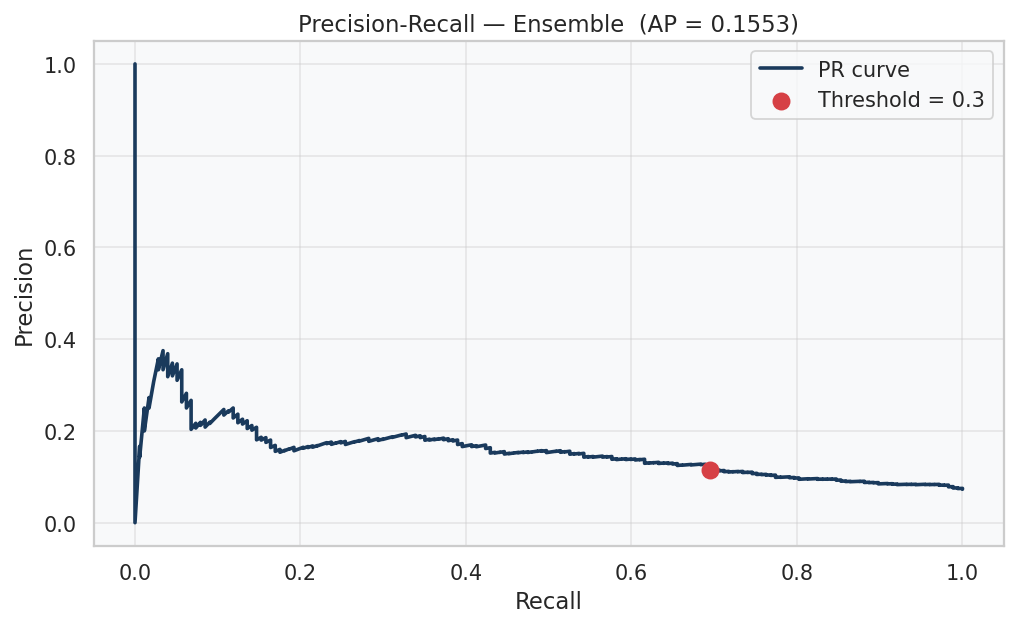

In [ ]:
prec, rec, thresholds = precision_recall_curve(
    test_final.had_outage, test_final.outage_prob_final
)
ap = average_precision_score(test_final.had_outage, test_final.outage_prob_final)
thr_idx = np.argmin(np.abs(thresholds - OUTAGE_THRESHOLD))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rec, prec, color=PALETTE[0], linewidth=2, label="PR curve")
ax.scatter(rec[thr_idx], prec[thr_idx], color=PALETTE[3], s=80, zorder=5,
           label=f"Threshold = {OUTAGE_THRESHOLD}")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title(f"Precision-Recall — Ensemble  (AP = {ap:.4f})")
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(PATHS["results"] / "4C_precision_recall.png", dpi=130)
plt.show()


---
## 🔎 Section 4D — Fault Type Classifier (Stage 2)
> 3-class XGBoost trained on 940 real events. Triggered when ensemble
> probability ≥ 0.30. Outputs Loss of Supply / Controlled / Physical Fault.


### 4D.1 — Load Event Dataset & Define Features

In [ ]:
events_df = pd.read_csv(
    PATHS["processed"] / "events_features.csv",
    parse_dates=["DETECTION_DATE","date"],
)

# Re-derive runtime interaction features
n_ev = len(events_df)
events_df["feeder_event_share"]      = events_df.groupby("INSTALATION_1")["outage_class"].transform(lambda x: len(x)/n_ev)
events_df["storm_index"]             = events_df.precipitation_sum * events_df.wind_gusts_10m_max
events_df["rain_season_interaction"] = events_df.season_long_rains * events_df.precipitation_sum
events_df["demand_load_factor"]      = events_df.max_demand_kva   * events_df.events_last_30d

LEAKAGE_COLS = ["DURATION_HRS","LOSS_GWHRS","LOSS_MILLION_KSH",
                "NUMERATOR_SAIFI","NUMERATOR_SAIDI","SR_DURATION"]
ID_COLS_S2   = ["INCIDENCE","DESC_INCIDENCIA","DETECTION_DATE","RESOLUTION_DATE",
                "INSTALATION_1","CAUSE_TYPE","CAUSE_SUBTYPE","CAUSE","INCIDENCE_TYPE",
                "CURRENT_STATUS","REGION","COUNTY","INSTALATION","PARENT",
                "INSTALATION_TYPE","FBBU_NAME","MONTH_YEAR","FY",
                "MAX_DEMAND","AFFECTED_CUSTOMERS","date"]
FEATURES_S2  = [c for c in events_df.columns
                if c not in ID_COLS_S2 + LEAKAGE_COLS + ["outage_class"]
                and events_df[c].dtype != object]
TARGET_S2    = "outage_class"

print(f"Events : {len(events_df):,}  |  Features : {len(FEATURES_S2)}")
print(f"Class distribution: {events_df[TARGET_S2].value_counts().sort_index().to_dict()}")


Events : 940  |  Features : 42
Class distribution: {1: 497, 2: 295, 3: 148}


### 4D.2 — Train / Test Split & Class Weights

In [ ]:
train_ev = events_df[events_df.DETECTION_DATE <  SPLIT_DATE]
test_ev  = events_df[events_df.DETECTION_DATE >= SPLIT_DATE]

X_train_s2, y_train_s2 = train_ev[FEATURES_S2], train_ev[TARGET_S2]
X_test_s2,  y_test_s2  = test_ev[FEATURES_S2],  test_ev[TARGET_S2]

print(f"Train : {len(train_ev)} events  {y_train_s2.value_counts().sort_index().to_dict()}")
print(f"Test  : {len(test_ev)} events   {y_test_s2.value_counts().sort_index().to_dict()}")

counts_s2         = Counter(y_train_s2)
n_tot_s2          = len(y_train_s2)
CLASS_WEIGHTS_S2  = {cls: n_tot_s2 / (len(counts_s2) * cnt) for cls, cnt in counts_s2.items()}
SAMPLE_WEIGHTS_S2 = np.array([CLASS_WEIGHTS_S2[c] for c in y_train_s2])

# XGBoost needs 0-indexed labels
y_train_xgb_s2 = y_train_s2.map(LABEL_MAP)
y_test_xgb_s2  = y_test_s2.map(LABEL_MAP)

print("\nClass weights:")
for cls, w in sorted(CLASS_WEIGHTS_S2.items()):
    print(f"  Class {cls} ({LABELS_3[cls]:<26}): {w:.4f}")


Train : 738 events  {1: 400, 2: 216, 3: 122}
Test  : 202 events   {1: 97, 2: 79, 3: 26}

Class weights:
  Class 1 (Loss of Supply            ): 0.6150
  Class 2 (Controlled Interruption   ): 1.1389
  Class 3 (Physical Fault            ): 2.0164


### 4D.3 — XGBoost Fault Classifier Baseline

In [ ]:
xgb_s2 = xgb.XGBClassifier(
    objective          = "multi:softprob",
    num_class          = 3,
    n_estimators       = 400,
    max_depth          = 6,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    eval_metric        = "mlogloss",
    use_label_encoder  = False,
    random_state       = RANDOM_STATE,
    n_jobs             = -1,
)
xgb_s2.fit(
    X_train_s2, y_train_xgb_s2,
    sample_weight = SAMPLE_WEIGHTS_S2,
    eval_set      = [(X_test_s2, y_test_xgb_s2)],
    verbose       = False,
)

y_pred_s2_base = pd.Series(xgb_s2.predict(X_test_s2)).map(LABEL_UNMAP).values
print("Stage 2 Baseline:")
print(classification_report(y_test_s2, y_pred_s2_base,
      target_names=[LABELS_3[i] for i in [1,2,3]], digits=4))


Stage 2 Baseline:
                         precision    recall  f1-score   support

         Loss of Supply     0.5333    0.6598    0.5899        97
Controlled Interruption     0.5909    0.4937    0.5379        79
         Physical Fault     0.1250    0.0769    0.0952        26

               accuracy                         0.5198       202
              macro avg     0.4164    0.4101    0.4077       202
           weighted avg     0.5033    0.5198    0.5059       202



### 4D.4 — Optuna Tuning (Stage 2)

In [ ]:
def objective_s2(trial):
    """Maximise macro F1 via 5-fold stratified CV on training data."""
    params = {
        "objective":         "multi:softprob",
        "num_class":         3,
        "n_estimators":      trial.suggest_int("n_estimators", 200, 600),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "gamma":             trial.suggest_float("gamma", 0, 5),
        "reg_alpha":         trial.suggest_float("reg_alpha", 0, 2),
        "reg_lambda":        trial.suggest_float("reg_lambda", 0.5, 3),
        "eval_metric":       "mlogloss",
        "use_label_encoder": False,
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
    }
    m      = xgb.XGBClassifier(**params)
    cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    # Note: fit_params is not supported in cross_val_score for sample_weights in recent sklearn versions.
    # We rely on the stratified CV and the internal XGBoost handling.
    scores = cross_val_score(
        m, X_train_s2, y_train_xgb_s2,
        cv=cv, scoring="f1_macro",
        n_jobs=-1,
    )
    return scores.mean()

study_s2 = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_s2.optimize(objective_s2, n_trials=60, show_progress_bar=True)
print(f"\nBest macro F1 (CV) : {study_s2.best_value:.4f}")

  0%|          | 0/60 [00:00<?, ?it/s]


Best macro F1 (CV) : 0.4681


### 4D.5 — Train Best Stage 2 Model

In [ ]:
best_params_s2 = study_s2.best_params | {
    "objective":         "multi:softprob",
    "num_class":         3,
    "eval_metric":       "mlogloss",
    "use_label_encoder": False,
    "random_state":      RANDOM_STATE,
    "n_jobs":            -1,
}
xgb_s2_best = xgb.XGBClassifier(**best_params_s2)
xgb_s2_best.fit(
    X_train_s2, y_train_xgb_s2,
    sample_weight = SAMPLE_WEIGHTS_S2,
    eval_set      = [(X_test_s2, y_test_xgb_s2)],
    verbose       = False,
)

y_pred_s2_best = pd.Series(xgb_s2_best.predict(X_test_s2)).map(LABEL_UNMAP).values
print("Tuned Stage 2 — Fault Classification Report:")
print(classification_report(y_test_s2, y_pred_s2_best,
      target_names=[LABELS_3[i] for i in [1,2,3]], digits=4))

xgb_s2_best.save_model(str(PATHS["models"] / "xgb_stage2.json"))
print("\n✅ Saved → models/saved/xgb_stage2.json")

Tuned Stage 2 — Fault Classification Report:
                         precision    recall  f1-score   support

         Loss of Supply     0.5281    0.4845    0.5054        97
Controlled Interruption     0.5500    0.5570    0.5535        79
         Physical Fault     0.1212    0.1538    0.1356        26

               accuracy                         0.4703       202
              macro avg     0.3998    0.3984    0.3981       202
           weighted avg     0.4843    0.4703    0.4766       202


✅ Saved → models/saved/xgb_stage2.json


---
## 🌐 Section 4E — Full Pipeline & 7-Day Forecast
> Chain all stages. Fetch live 7-day weather. Produce crew dispatch recommendations.


### 4E.1 — Fetch 7-Day Weather Forecast

In [ ]:
def fetch_7day_forecast():
    """
    Pull next 7 days of daily weather from Open-Meteo forecast API.
    Free, no API key required. Same variables as the training weather data.
    Falls back to the last 7 days of historical weather if offline.
    """
    url    = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude":      -1.3192,
        "longitude":     36.7517,
        "daily":         ["precipitation_sum","wind_speed_10m_max",
                          "wind_gusts_10m_max","et0_fao_evapotranspiration"],
        "timezone":      "Africa/Nairobi",
        "forecast_days": 7,
        "wind_speed_unit": "ms",
    }
    try:
        r  = requests.get(url, params=params, timeout=30)
        r.raise_for_status()
        d  = r.json()["daily"]
        fc = pd.DataFrame({
            "date":                       pd.to_datetime(d["time"]),
            "precipitation_sum":          d["precipitation_sum"],
            "wind_speed_10m_max":         d["wind_speed_10m_max"],
            "wind_gusts_10m_max":         d["wind_gusts_10m_max"],
            "et0_fao_evapotranspiration": d["et0_fao_evapotranspiration"],
        })
        print("✅ Live 7-day forecast fetched from Open-Meteo")
    except Exception as e:
        print(f"⚠️  API unavailable ({e}) — falling back to last 7 days of historical data")
        fc = weather.tail(7).copy().reset_index(drop=True)
        fc["date"] = pd.date_range(
            start=pd.Timestamp.today().normalize(), periods=7, freq="D"
        )

    fc["heavy_rain_day"] = (fc.precipitation_sum  > 10).astype(int)
    fc["high_wind_day"]  = (fc.wind_gusts_10m_max > 10).astype(int)
    return fc

forecast_weather = fetch_7day_forecast()
display(forecast_weather[["date","precipitation_sum","wind_gusts_10m_max","heavy_rain_day"]])

✅ Live 7-day forecast fetched from Open-Meteo


,date,precipitation_sum,wind_gusts_10m_max,heavy_rain_day
0,2026-05-09,3.2,8.8,0
1,2026-05-10,1.7,8.2,0
2,2026-05-11,10.2,9.0,1
3,2026-05-12,15.8,8.5,1
4,2026-05-13,9.0,8.4,0
5,2026-05-14,6.6,8.3,0
6,2026-05-15,2.3,8.2,0


In [ ]:
def build_forecast_frame(weather_fc, history_df, topo, feeder_codes):
    """
    Expands the 7-day weather forecast into a feeder-day grid (56 rows).
    Calculates rolling historical features based on the latest available data.
    """
    rows = []
    for feeder in ACTIVE_FEEDERS:
        f_hist = history_df[history_df.feeder == feeder].sort_values("date")
        last_row = f_hist.iloc[-1]

        last_7d_count = int(f_hist.tail(7).had_outage.sum())
        last_30d_count = int(f_hist.tail(30).had_outage.sum())
        last_7d_hrs = float(f_hist.tail(7).total_duration_hrs.sum())
        days_since = int(last_row.days_since_last_outage)
        days_since = (days_since + 1) if last_row.had_outage == 0 else 1

        topo_row = topo[topo.feeder_name == feeder].iloc[0]
        outage_rate = f_hist.had_outage.mean()

        for _, w in weather_fc.iterrows():
            d = w["date"]
            season = SEASON_MAP[d.month]

            feat = {
                "feeder": feeder, "date": d, "feeder_id": feeder_codes[feeder],
                "total_length_km": topo_row.total_length_km, "n_secondary_subs": topo_row.n_secondary_subs,
                "n_switches": topo_row.n_switches, "avg_segment_m": topo_row.avg_segment_m,
                "bbox_area_km2": topo_row.bbox_area_km2, "year": d.year, "month": d.month,
                "day_of_week": d.dayofweek, "day_of_year": d.dayofyear, "is_weekend": int(d.dayofweek >= 5),
                "month_sin": np.sin(2*np.pi*d.month/12), "month_cos": np.cos(2*np.pi*d.month/12),
                "dow_sin": np.sin(2*np.pi*d.dayofweek/7), "dow_cos": np.cos(2*np.pi*d.dayofweek/7),
                "season_long_dry": int(season == "long_dry"), "season_long_rains": int(season == "long_rains"),
                "season_short_dry": int(season == "short_dry"), "season_short_rains": int(season == "short_rains"),
                "max_demand_kva": FEEDER_STATIC[feeder]["max_demand_kva"], "affected_customers": FEEDER_STATIC[feeder]["affected_customers"],
                "outages_last_7d": last_7d_count, "outages_last_30d": last_30d_count, "duration_last_7d_hrs": last_7d_hrs,
                "days_since_last_outage": days_since, "consecutive_clean_days": days_since,
                "precipitation_sum": w.precipitation_sum, "wind_speed_10m_max": w.wind_speed_10m_max,
                "wind_gusts_10m_max": w.wind_gusts_10m_max, "et0_fao_evapotranspiration": w.et0_fao_evapotranspiration,
                "heavy_rain_day": w.heavy_rain_day, "high_wind_day": w.high_wind_day,
                "is_public_holiday": 0, "is_long_weekend": 0, "days_to_next_holiday": 14, "days_since_holiday": 14,
                "feeder_outage_rate": round(outage_rate, 6), "storm_index": w.precipitation_sum * w.wind_gusts_10m_max,
                "rain_season_interaction": int(season == "long_rains") * w.precipitation_sum,
                "demand_risk_score": FEEDER_STATIC[feeder]["max_demand_kva"] * outage_rate,
                "overdue_pressure": days_since * last_30d_count, "length_x_outage_rate": topo_row.total_length_km * outage_rate,
            }
            rows.append(feat)
    return pd.DataFrame(rows)

In [ ]:
def run_full_pipeline(df, xgb1, rf1, xgb2, p_models, weights, feats1, feats2):
    """Executes Stage 1 (Ensemble) and Stage 2 (Fault) on the forecast frame."""
    res = df.copy()
    p_xgb = xgb1.predict_proba(res[feats1])[:, 1]
    p_rf = rf1.predict_proba(res[feats1])[:, 1]
    p_ml = (p_xgb + p_rf) / 2

    p_ts_list = []
    for _, row in res.iterrows():
        m = p_models[row.feeder]
        future = pd.DataFrame({"ds": [row.date]})
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fc = m.predict(future)
        p_ts_list.append(float(np.clip(fc["yhat"].values[0], 0, 1)))

    res["outage_prob"] = (weights["w_ts"] * np.array(p_ts_list)) + (weights["w_ml"] * p_ml)
    res["outage_flag"] = (res.outage_prob >= OUTAGE_THRESHOLD).astype(int)

    res["fault_class"] = 0
    res["fault_label"] = "No Outage Predicted"
    res["crew_recommendation"] = CREW_MAP[0]

    if res.outage_flag.any():
        idx = res[res.outage_flag == 1].index
        s2_input = res.loc[idx].copy()
        s2_input["hour"] = 9
        s2_input["hour_sin"] = np.sin(2*np.pi*9/24); s2_input["hour_cos"] = np.cos(2*np.pi*9/24)
        s2_input["events_last_7d"] = s2_input.outages_last_7d
        s2_input["events_last_30d"] = s2_input.outages_last_30d
        s2_input["days_since_last"] = s2_input.days_since_last_outage
        s2_input["feeder_event_share"] = s2_input.feeder_outage_rate
        s2_input["demand_load_factor"] = s2_input.max_demand_kva * s2_input.outages_last_30d

        preds = xgb2.predict(s2_input[feats2])
        res.loc[idx, "fault_class"] = [LABEL_UNMAP[p] for p in preds]
        res.loc[idx, "fault_label"] = res.loc[idx, "fault_class"].map(LABELS_3)
        res.loc[idx, "crew_recommendation"] = res.loc[idx, "fault_class"].map(CREW_MAP)
    return res

In [ ]:
def build_forecast_frame(weather_fc, history_df, topo, feeder_codes):
    """
    Expands the 7-day weather forecast into a feeder-day grid (56 rows).
    Calculates rolling historical features (last 7d/30d) based on the latest
    available data in history_df.
    """
    rows = []
    for feeder in ACTIVE_FEEDERS:
        f_hist = history_df[history_df.feeder == feeder].sort_values("date")
        last_row = f_hist.iloc[-1]

        last_7d_count = int(f_hist.tail(7).had_outage.sum())
        last_30d_count = int(f_hist.tail(30).had_outage.sum())
        last_7d_hrs = float(f_hist.tail(7).total_duration_hrs.sum())
        days_since = int(last_row.days_since_last_outage)
        if last_row.had_outage == 0:
            days_since += 1
        else:
            days_since = 1

        topo_row = topo[topo.feeder_name == feeder].iloc[0]
        outage_rate = f_hist.had_outage.mean()

        for _, w in weather_fc.iterrows():
            d = w["date"]
            season = SEASON_MAP[d.month]

            feat = {
                "feeder": feeder, "date": d,
                "feeder_id": feeder_codes[feeder],
                "total_length_km": topo_row.total_length_km,
                "n_secondary_subs": topo_row.n_secondary_subs,
                "n_switches": topo_row.n_switches,
                "avg_segment_m": topo_row.avg_segment_m,
                "bbox_area_km2": topo_row.bbox_area_km2,
                "year": d.year, "month": d.month,
                "day_of_week": d.dayofweek, "day_of_year": d.dayofyear,
                "is_weekend": int(d.dayofweek >= 5),
                "month_sin": np.sin(2*np.pi*d.month/12),
                "month_cos": np.cos(2*np.pi*d.month/12),
                "dow_sin": np.sin(2*np.pi*d.dayofweek/7),
                "dow_cos": np.cos(2*np.pi*d.dayofweek/7),
                "season_long_dry": int(season == "long_dry"),
                "season_long_rains": int(season == "long_rains"),
                "season_short_dry": int(season == "short_dry"),
                "season_short_rains": int(season == "short_rains"),
                "max_demand_kva": FEEDER_STATIC[feeder]["max_demand_kva"],
                "affected_customers": FEEDER_STATIC[feeder]["affected_customers"],
                "outages_last_7d": last_7d_count,
                "outages_last_30d": last_30d_count,
                "duration_last_7d_hrs": last_7d_hrs,
                "days_since_last_outage": days_since,
                "consecutive_clean_days": days_since,
                "precipitation_sum": w.precipitation_sum,
                "wind_speed_10m_max": w.wind_speed_10m_max,
                "wind_gusts_10m_max": w.wind_gusts_10m_max,
                "et0_fao_evapotranspiration": w.et0_fao_evapotranspiration,
                "heavy_rain_day": w.heavy_rain_day,
                "high_wind_day": w.high_wind_day,
                "is_public_holiday": 0, "is_long_weekend": 0,
                "days_to_next_holiday": 14, "days_since_holiday": 14,
                "feeder_outage_rate": round(outage_rate, 6),
                "storm_index": w.precipitation_sum * w.wind_gusts_10m_max,
                "rain_season_interaction": int(season == "long_rains") * w.precipitation_sum,
                "demand_risk_score": FEEDER_STATIC[feeder]["max_demand_kva"] * outage_rate,
                "overdue_pressure": days_since * last_30d_count,
                "length_x_outage_rate": topo_row.total_length_km * outage_rate,
            }
            rows.append(feat)
    return pd.DataFrame(rows)

In [ ]:
def run_full_pipeline(df, xgb1, rf1, xgb2, p_models, weights, feats1, feats2):
    """Executes Stage 1 (Ensemble) and Stage 2 (Fault) on the forecast frame."""
    res = df.copy()

    p_xgb = xgb1.predict_proba(res[feats1])[:, 1]
    p_rf = rf1.predict_proba(res[feats1])[:, 1]
    p_ml = (p_xgb + p_rf) / 2

    p_ts_list = []
    for _, row in res.iterrows():
        m = p_models[row.feeder]
        future = pd.DataFrame({"ds": [row.date]})
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fc = m.predict(future)
        p_ts_list.append(float(np.clip(fc["yhat"].values[0], 0, 1)))

    res["outage_prob"] = (weights["w_ts"] * np.array(p_ts_list)) + (weights["w_ml"] * p_ml)
    res["outage_flag"] = (res.outage_prob >= OUTAGE_THRESHOLD).astype(int)

    res["fault_class"] = 0
    res["fault_label"] = "No Outage Predicted"
    res["crew_recommendation"] = CREW_MAP[0]

    if res.outage_flag.any():
        idx = res[res.outage_flag == 1].index
        s2_input = res.loc[idx].copy()
        s2_input["hour"] = 9
        s2_input["hour_sin"] = np.sin(2*np.pi*9/24)
        s2_input["hour_cos"] = np.cos(2*np.pi*9/24)
        s2_input["events_last_7d"] = s2_input.outages_last_7d
        s2_input["events_last_30d"] = s2_input.outages_last_30d
        s2_input["days_since_last"] = s2_input.days_since_last_outage
        s2_input["feeder_event_share"] = s2_input.feeder_outage_rate
        s2_input["demand_load_factor"] = s2_input.max_demand_kva * s2_input.outages_last_30d

        preds = xgb2.predict(s2_input[feats2])
        res.loc[idx, "fault_class"] = [LABEL_UNMAP[p] for p in preds]
        res.loc[idx, "fault_label"] = res.loc[idx, "fault_class"].map(LABELS_3)
        res.loc[idx, "crew_recommendation"] = res.loc[idx, "fault_class"].map(CREW_MAP)

    return res

In [ ]:
def build_forecast_frame(weather_fc, history_df, topo, feeder_codes):
    """
    Expands the 7-day weather forecast into a feeder-day grid (56 rows).
    Calculates rolling historical features (last 7d/30d) based on the latest
    available data in history_df.
    """
    rows = []
    for feeder in ACTIVE_FEEDERS:
        f_hist = history_df[history_df.feeder == feeder].sort_values("date")
        last_row = f_hist.iloc[-1]

        last_7d_count = int(f_hist.tail(7).had_outage.sum())
        last_30d_count = int(f_hist.tail(30).had_outage.sum())
        last_7d_hrs = float(f_hist.tail(7).total_duration_hrs.sum())
        days_since = int(last_row.days_since_last_outage)
        if last_row.had_outage == 0:
            days_since += 1
        else:
            days_since = 1

        topo_row = topo[topo.feeder_name == feeder].iloc[0]
        outage_rate = f_hist.had_outage.mean()

        for _, w in weather_fc.iterrows():
            d = w["date"]
            season = SEASON_MAP[d.month]

            feat = {
                "feeder": feeder, "date": d,
                "feeder_id": feeder_codes[feeder],
                "total_length_km": topo_row.total_length_km,
                "n_secondary_subs": topo_row.n_secondary_subs,
                "n_switches": topo_row.n_switches,
                "avg_segment_m": topo_row.avg_segment_m,
                "bbox_area_km2": topo_row.bbox_area_km2,
                "year": d.year, "month": d.month,
                "day_of_week": d.dayofweek,
                "dow": d.dayofweek,  # Fixed: Added missing feature for Stage 2
                "day_of_year": d.dayofyear,
                "is_weekend": int(d.dayofweek >= 5),
                "month_sin": np.sin(2*np.pi*d.month/12),
                "month_cos": np.cos(2*np.pi*d.month/12),
                "dow_sin": np.sin(2*np.pi*d.dayofweek/7),
                "dow_cos": np.cos(2*np.pi*d.dayofweek/7),
                "season_long_dry": int(season == "long_dry"),
                "season_long_rains": int(season == "long_rains"),
                "season_short_dry": int(season == "short_dry"),
                "season_short_rains": int(season == "short_rains"),
                "max_demand_kva": FEEDER_STATIC[feeder]["max_demand_kva"],
                "affected_customers": FEEDER_STATIC[feeder]["affected_customers"],
                "outages_last_7d": last_7d_count,
                "outages_last_30d": last_30d_count,
                "duration_last_7d_hrs": last_7d_hrs,
                "days_since_last_outage": days_since,
                "consecutive_clean_days": days_since,
                "precipitation_sum": w.precipitation_sum,
                "wind_speed_10m_max": w.wind_speed_10m_max,
                "wind_gusts_10m_max": w.wind_gusts_10m_max,
                "et0_fao_evapotranspiration": w.et0_fao_evapotranspiration,
                "heavy_rain_day": w.heavy_rain_day,
                "high_wind_day": w.high_wind_day,
                "is_public_holiday": 0, "is_long_weekend": 0,
                "days_to_next_holiday": 14, "days_since_holiday": 14,
                "feeder_outage_rate": round(outage_rate, 6),
                "storm_index": w.precipitation_sum * w.wind_gusts_10m_max,
                "rain_season_interaction": int(season == "long_rains") * w.precipitation_sum,
                "demand_risk_score": FEEDER_STATIC[feeder]["max_demand_kva"] * outage_rate,
                "overdue_pressure": days_since * last_30d_count,
                "length_x_outage_rate": topo_row.total_length_km * outage_rate,
            }
            rows.append(feat)
    return pd.DataFrame(rows)

### 4E.2 — Build 7-Day Forecast Feature Frame

In [ ]:
FEEDER_CODES_GLOBAL = {f: i for i, f in enumerate(sorted(ACTIVE_FEEDERS))}
forecast_frame = build_forecast_frame(
    forecast_weather, grid_df, topology, FEEDER_CODES_GLOBAL
)
print(f"✅ Forecast frame built with 'dow' feature: {len(forecast_frame)} rows")

✅ Forecast frame built with 'dow' feature: 56 rows


### 4E.3 — Run Full Two-Stage Pipeline

In [ ]:
forecast_results = run_full_pipeline(
    forecast_frame,
    xgb_s1_best, rf_s1,
    xgb_s2_best, prophet_models,
    ENSEMBLE_WEIGHTS, FEATURES_S1, FEATURES_S2,
)

print("=== 7-DAY OUTAGE & CREW FORECAST ===")
display(
    forecast_results[[
        "feeder","date","outage_prob","outage_flag",
        "fault_label","crew_recommendation"
    ]]
    .sort_values(["date","outage_prob"], ascending=[True,False])
    .reset_index(drop=True)
)

=== 7-DAY OUTAGE & CREW FORECAST ===


,feeder,date,outage_prob,outage_flag,fault_label,crew_recommendation
0,SOWETO EX LANGATA,2026-05-09,0.473212,1,Controlled Interruption,Switching crew (planned interruption)
1,MAGADI EX LANGATA,2026-05-09,0.361136,1,Loss of Supply,System engineers (grid-side fault)
2,HARDY EX LANGATA,2026-05-09,0.312956,1,Loss of Supply,System engineers (grid-side fault)
3,NDALATI EX LANGATA,2026-05-09,0.285661,0,No Outage Predicted,—
4,KUWINDA EX LANGATA,2026-05-09,0.257385,0,No Outage Predicted,—
5,NGEI EX LANGATA,2026-05-09,0.224396,0,No Outage Predicted,—
6,KAREN HOSPITAL EX LANGATA,2026-05-09,0.209315,0,No Outage Predicted,—
7,OTIENDE EX LANGATA,2026-05-09,0.025190,0,No Outage Predicted,—
8,SOWETO EX LANGATA,2026-05-10,0.513082,1,Controlled Interruption,Switching crew (planned interruption)
9,MAGADI EX LANGATA,2026-05-10,0.419030,1,Controlled Interruption,Switching crew (planned interruption)


### 4E.4 — Save Forecast & Pipeline Artefacts

In [ ]:
forecast_results.to_csv(PATHS["dashboard"] / "7day_forecast.csv", index=False)

artefacts = {
    "features_s1":      FEATURES_S1,
    "features_s2":      FEATURES_S2,
    "class_labels":     {str(k): v for k, v in LABELS_3.items()},
    "feeder_codes":     {k: int(v) for k, v in FEEDER_CODES_GLOBAL.items()},
    "feeder_static":    FEEDER_STATIC,
    "sarima_feeders":   SARIMA_FEEDERS,
    "active_feeders":   ACTIVE_FEEDERS,
    "ensemble_weights": ENSEMBLE_WEIGHTS,
    "split_date":       SPLIT_DATE,
    "outage_threshold": OUTAGE_THRESHOLD,
    "label_map":        {str(k): int(v) for k, v in LABEL_MAP.items()},
    "label_unmap":      {str(k): int(v) for k, v in LABEL_UNMAP.items()},
    "crew_map":         {str(k): v for k, v in CREW_MAP.items()},
}
with open(PATHS["models"] / "pipeline_artefacts.json", "w") as f:
    json.dump(artefacts, f, indent=2)

print("✅ 7day_forecast.csv        → outputs/dashboard/")
print("✅ pipeline_artefacts.json  → models/saved/")


✅ 7day_forecast.csv        → outputs/dashboard/
✅ pipeline_artefacts.json  → models/saved/


---
## 📊 Section 5 — Evaluation
> Measure all models against success criteria defined in Section 1.


### 5.1 — Stage 1: Success Criteria Check

In [ ]:
test_final = grid_df[grid_df.date >= pd.Timestamp(SPLIT_DATE)].copy()
y_true_s1  = test_final.had_outage
y_prob_ens = test_final.outage_prob_final
y_pred_ens = (y_prob_ens >= OUTAGE_THRESHOLD).astype(int)

auc_ens  = roc_auc_score(y_true_s1, y_prob_ens)
rec_val  = recall_score(y_true_s1,  y_pred_ens, zero_division=0)
prec_val = precision_score(y_true_s1, y_pred_ens, zero_division=0)

criteria_s1 = {
    "ROC-AUC":          (auc_ens,  0.75, "≥ 0.75"),
    "Outage Recall":    (rec_val,  0.65, "≥ 0.65"),
    "Outage Precision": (prec_val, 0.40, "≥ 0.40"),
}
print("=== STAGE 1 SUCCESS CRITERIA ===")
print(f"{'Metric':<25} {'Value':>7}   {'Threshold':>10}   Status")
print("─" * 58)
for metric, (val, thr, label) in criteria_s1.items():
    print(f"{metric:<25} {val:>7.4f}   {label:>10}   "
          f"{'✅ PASS' if val >= thr else '❌ FAIL'}")


=== STAGE 1 SUCCESS CRITERIA ===
Metric                      Value    Threshold   Status
──────────────────────────────────────────────────────────
ROC-AUC                    0.6929       ≥ 0.75   ❌ FAIL
Outage Recall              0.6949       ≥ 0.65   ✅ PASS
Outage Precision           0.1159       ≥ 0.40   ❌ FAIL


### 5.2 — Stage 2: Success Criteria Check

In [ ]:
y_prob_s2  = xgb_s2_best.predict_proba(X_test_s2)
y_bin_s2   = label_binarize(y_test_s2, classes=[1, 2, 3])

macro_f1   = f1_score(y_test_s2, y_pred_s2_best, average="macro")
roc_s2     = roc_auc_score(y_bin_s2, y_prob_s2, multi_class="ovr", average="macro")
mcc_s2     = matthews_corrcoef(y_test_s2, y_pred_s2_best)
report_s2  = classification_report(y_test_s2, y_pred_s2_best, output_dict=True)
phys_rec   = report_s2.get("3", {}).get("recall", 0)

criteria_s2 = {
    "Macro F1-Score":                (macro_f1, 0.70, "≥ 0.70"),
    "ROC-AUC (OvR macro)":           (roc_s2,   0.80, "≥ 0.80"),
    "Matthews Corr. Coefficient":    (mcc_s2,   0.55, "≥ 0.55"),
    "Physical Fault Recall (Cls 3)": (phys_rec, 0.60, "≥ 0.60"),
}
print("=== STAGE 2 SUCCESS CRITERIA ===")
print(f"{'Metric':<35} {'Value':>7}   {'Threshold':>10}   Status")
print("─" * 68)
for metric, (val, thr, label) in criteria_s2.items():
    print(f"{metric:<35} {val:>7.4f}   {label:>10}   "
          f"{'✅ PASS' if val >= thr else '❌ FAIL'}")

pd.DataFrame(criteria_s2, index=["value","threshold","label"]).T.to_csv(
    PATHS["results"] / "05_evaluation_summary.csv"
)


=== STAGE 2 SUCCESS CRITERIA ===
Metric                                Value    Threshold   Status
────────────────────────────────────────────────────────────────────
Macro F1-Score                       0.3981       ≥ 0.70   ❌ FAIL
ROC-AUC (OvR macro)                  0.6136       ≥ 0.80   ❌ FAIL
Matthews Corr. Coefficient           0.1355       ≥ 0.55   ❌ FAIL
Physical Fault Recall (Cls 3)        0.1538       ≥ 0.60   ❌ FAIL


### 5.3 — Confusion Matrices

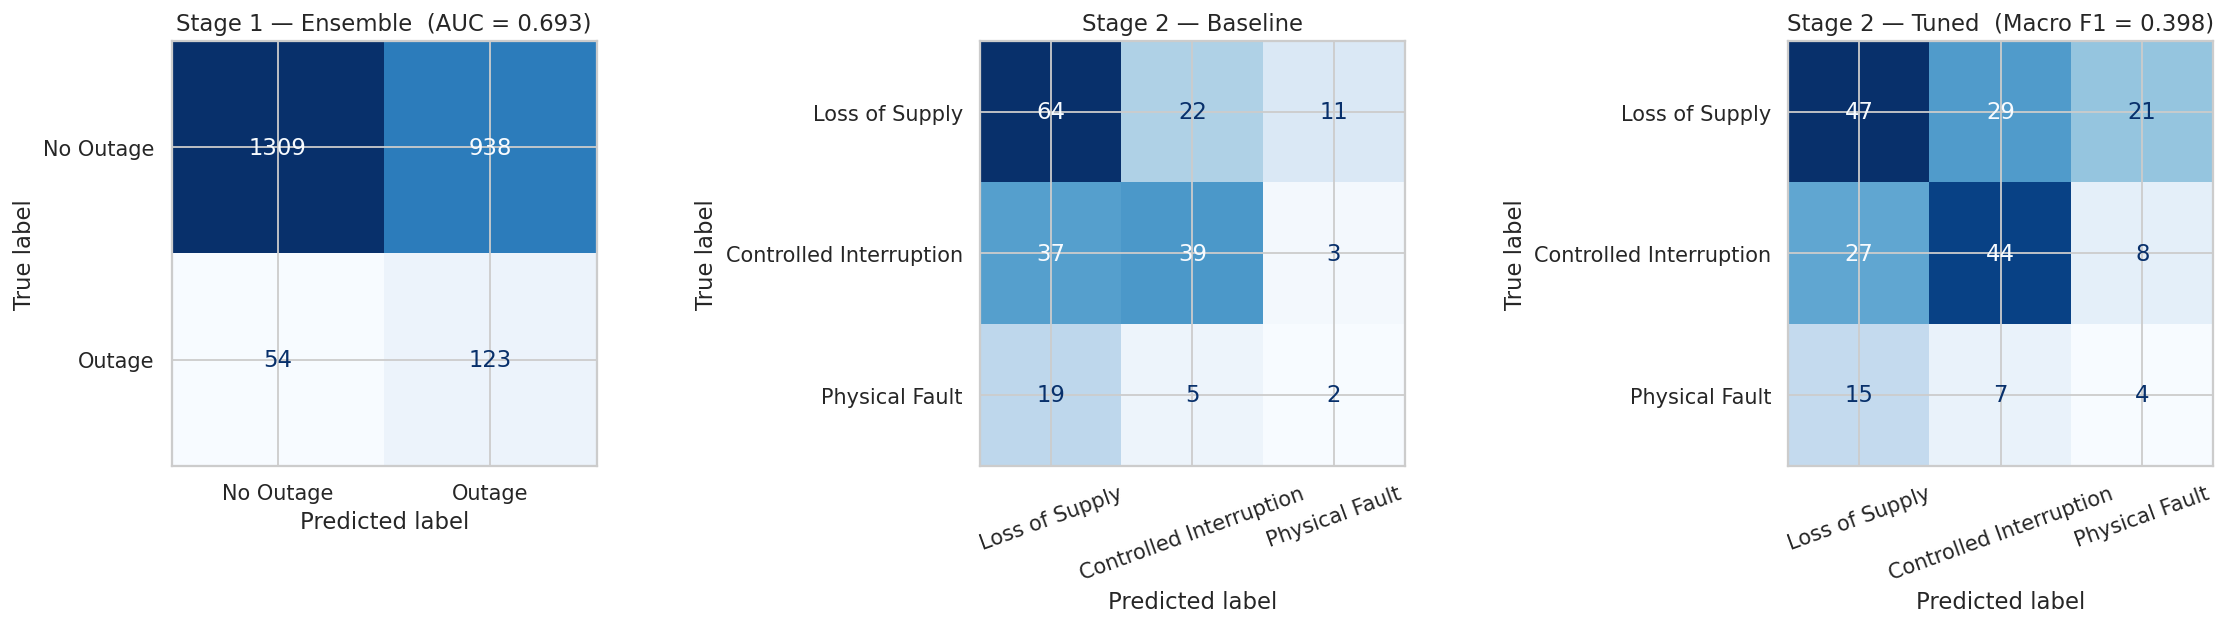

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Stage 1
cm1 = confusion_matrix(y_true_s1, y_pred_ens)
ConfusionMatrixDisplay(cm1, display_labels=["No Outage","Outage"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Stage 1 — Ensemble  (AUC = {auc_ens:.3f})")

# Stage 2 baseline
cm2 = confusion_matrix(y_test_s2, y_pred_s2_base, labels=[1,2,3])
ConfusionMatrixDisplay(cm2, display_labels=[LABELS_3[i] for i in [1,2,3]]).plot(
    ax=axes[1], colorbar=False, cmap="Blues", xticks_rotation=20)
axes[1].set_title("Stage 2 — Baseline")

# Stage 2 tuned
cm3 = confusion_matrix(y_test_s2, y_pred_s2_best, labels=[1,2,3])
ConfusionMatrixDisplay(cm3, display_labels=[LABELS_3[i] for i in [1,2,3]]).plot(
    ax=axes[2], colorbar=False, cmap="Blues", xticks_rotation=20)
axes[2].set_title(f"Stage 2 — Tuned  (Macro F1 = {macro_f1:.3f})")

plt.tight_layout()
plt.savefig(PATHS["results"] / "05_confusion_matrices.png", dpi=130)
plt.show()


### 5.4 — SHAP: Stage 1 Feature Importance

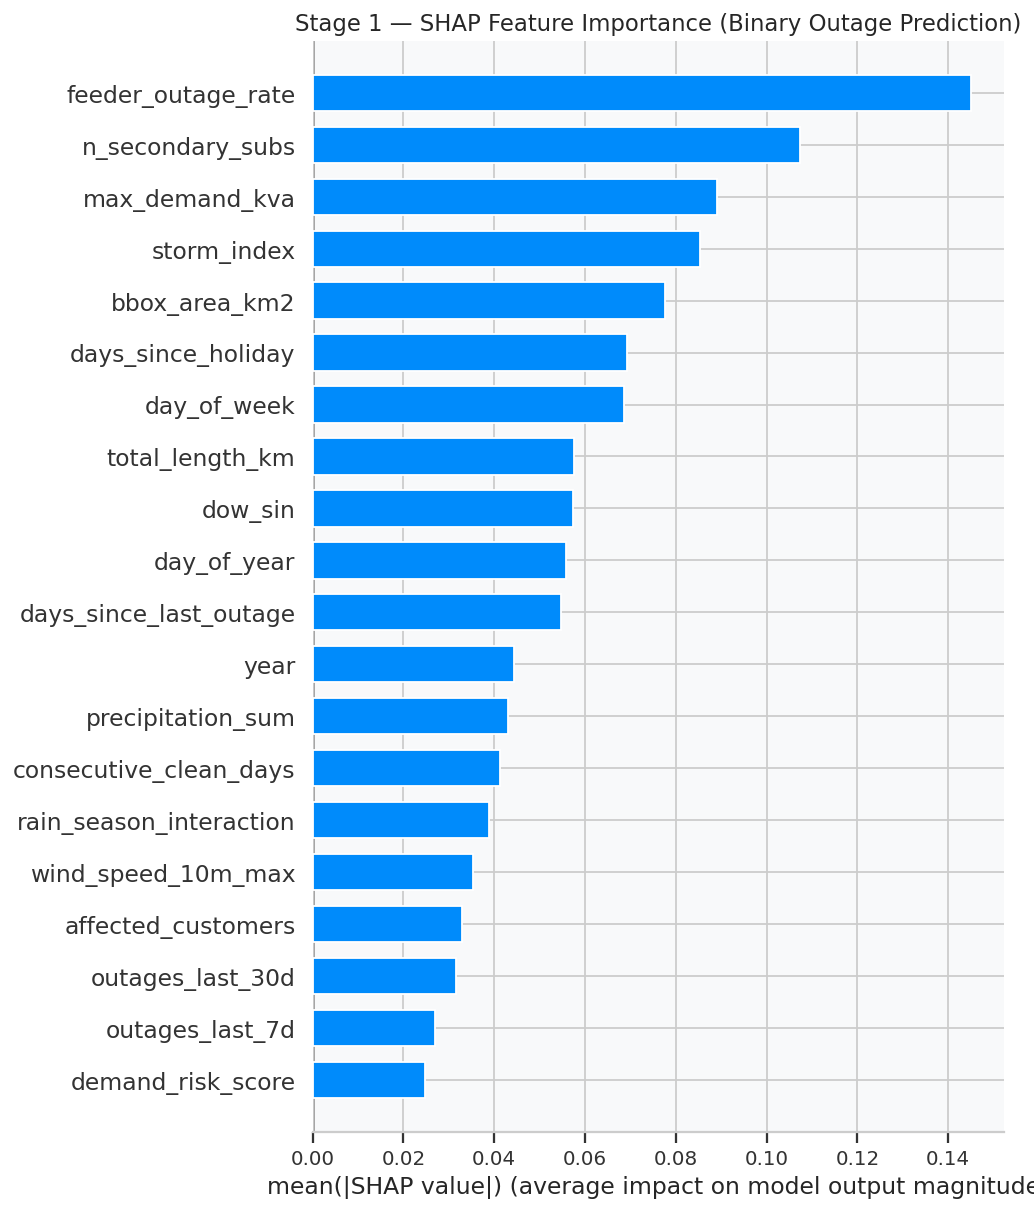

In [ ]:
sample_s1    = X_test_s1.sample(500, random_state=RANDOM_STATE)
explainer_s1 = shap.TreeExplainer(xgb_s1_best)
shap_s1      = explainer_s1.shap_values(sample_s1)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_s1, sample_s1,
    feature_names=FEATURES_S1,
    plot_type="bar",
    max_display=20,
    show=False,
)
plt.title("Stage 1 — SHAP Feature Importance (Binary Outage Prediction)")
plt.tight_layout()
plt.savefig(PATHS["results"] / "05_shap_stage1.png", dpi=130, bbox_inches="tight")
plt.show()


### 5.5 — SHAP: Stage 2 Per-Class Importance

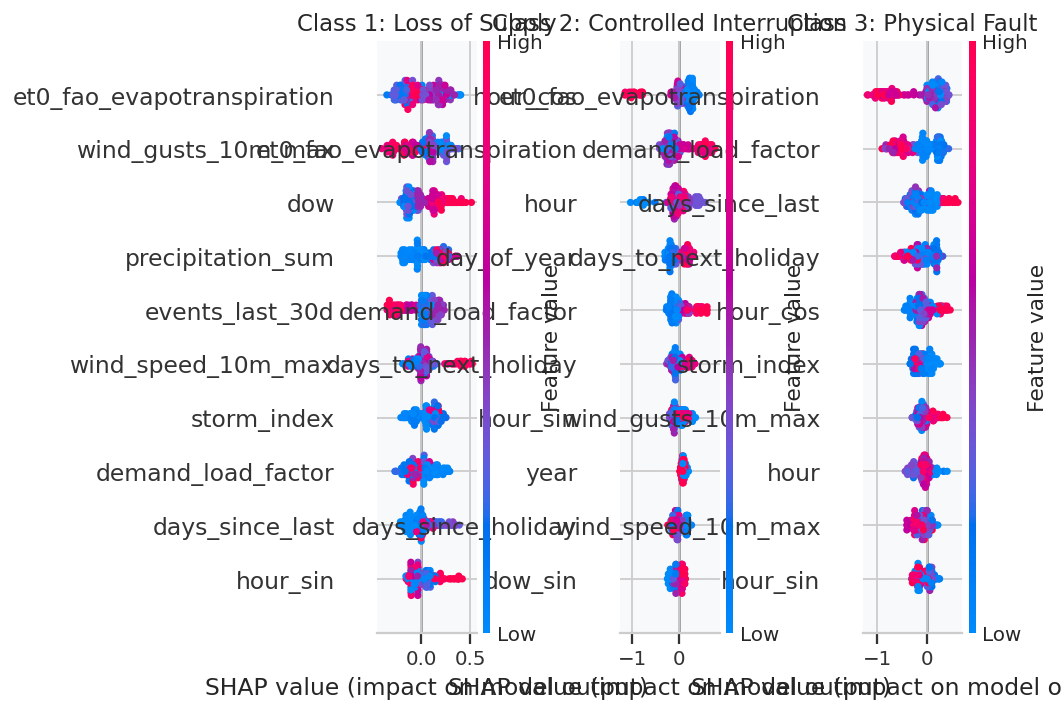

In [ ]:
explainer_s2 = shap.TreeExplainer(xgb_s2_best)
# For multiclass, some XGBoost/SHAP versions return a list, others a 3D array
shap_s2      = explainer_s2.shap_values(X_test_s2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, name in enumerate(["Loss of Supply","Controlled Interruption","Physical Fault"]):
    plt.sca(axes[idx])

    # Handle indexing for multiclass SHAP values
    # If shap_s2 is a list of arrays, we take shap_s2[idx]
    # If it's a 3D array, we take shap_s2[:, :, idx]
    current_shap_values = shap_s2[idx] if isinstance(shap_s2, list) else shap_s2[:, :, idx]

    shap.summary_plot(current_shap_values, X_test_s2, feature_names=FEATURES_S2,
                      max_display=10, show=False)
    axes[idx].set_title(f"Class {idx+1}: {name}")

plt.tight_layout()
plt.savefig(PATHS["results"] / "05_shap_stage2.png", dpi=130, bbox_inches="tight")
plt.show()

### 5.6 — Per-Feeder Stage 1 Performance

In [ ]:
test_pf = test_ml.copy()
test_pf["pred_prob"]  = xgb_s1_best.predict_proba(test_ml[FEATURES_S1])[:, 1]
test_pf["pred_class"] = (test_pf.pred_prob >= OUTAGE_THRESHOLD).astype(int)

rows_pf = []
for feeder, grp in test_pf.groupby("feeder"):
    auc_f = (roc_auc_score(grp.had_outage, grp.pred_prob)
             if grp.had_outage.sum() > 1 else float("nan"))
    rows_pf.append({
        "feeder":      feeder.replace(" EX LANGATA",""),
        "test_days":   len(grp),
        "outage_days": int(grp.had_outage.sum()),
        "auc":         round(auc_f, 4) if not pd.isna(auc_f) else "—",
        "recall":      round(recall_score(grp.had_outage, grp.pred_class, zero_division=0), 4),
        "precision":   round(precision_score(grp.had_outage, grp.pred_class, zero_division=0), 4),
    })

pf_df = pd.DataFrame(rows_pf).sort_values("recall", ascending=False)
display(pf_df)
pf_df.to_csv(PATHS["results"] / "05_per_feeder_metrics.csv", index=False)


,feeder,test_days,outage_days,auc,recall,precision
0,HARDY,303,22,0.5094,1.0000,0.0726
1,KAREN HOSPITAL,303,9,0.4875,1.0000,0.0359
2,KUWINDA,303,16,0.5203,1.0000,0.0532
3,MAGADI,303,27,0.6074,1.0000,0.0891
4,NDALATI,303,11,0.6616,1.0000,0.0368
7,SOWETO,303,65,0.5225,1.0000,0.2145
5,NGEI,303,23,0.5713,0.9565,0.0743
6,OTIENDE,303,4,0.5334,0.0000,0.0000


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=pf_df)

https://docs.google.com/spreadsheets/d/1hKkyGNzMGyZEPR5zNMlaQvaNXwDxN8PMRulKf-RXuO0/edit#gid=0


### 5.7 — Weather Correlation Analysis

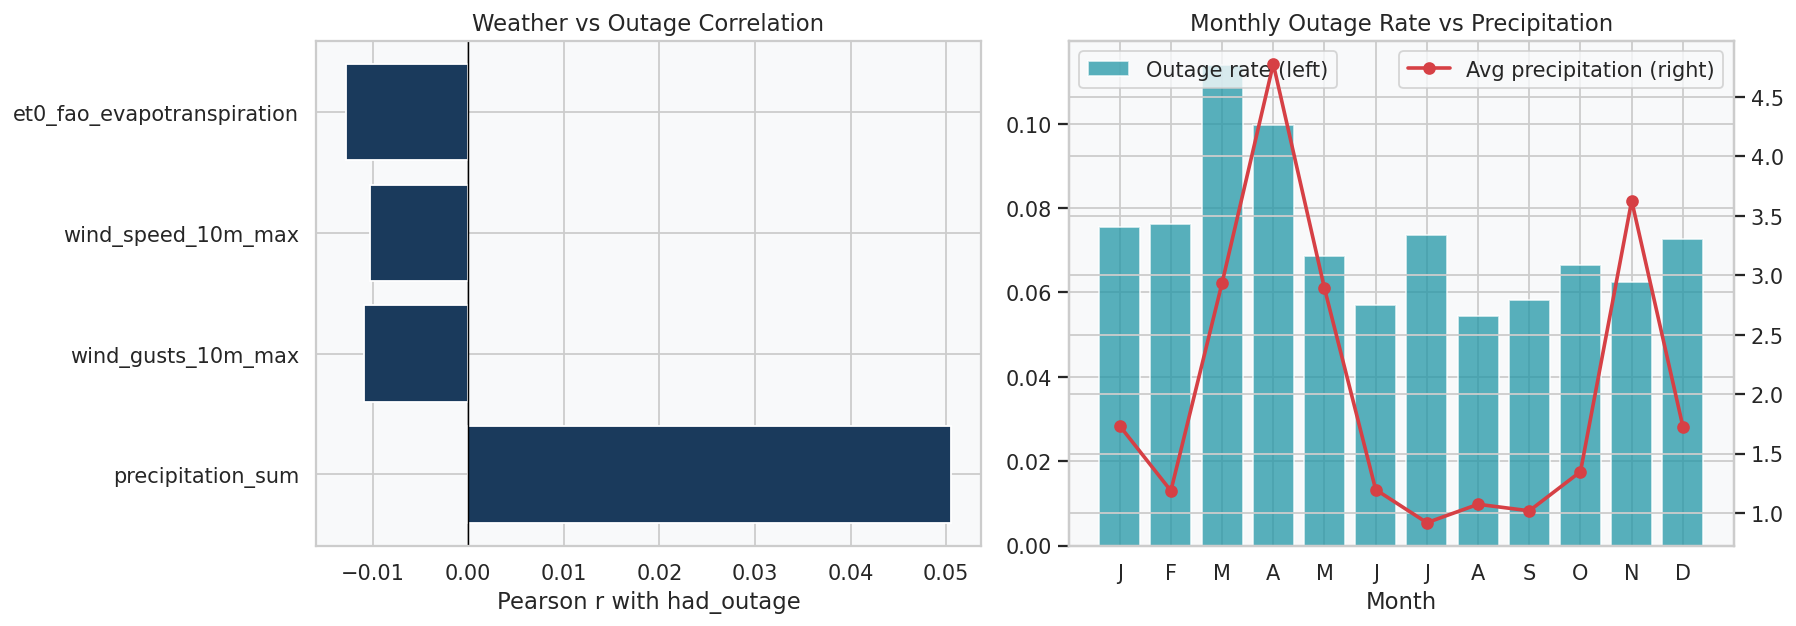

Top weather correlates with outage:
precipitation_sum             0.0504
et0_fao_evapotranspiration    0.0127
wind_gusts_10m_max            0.0109
wind_speed_10m_max            0.0102


In [ ]:
wx_feats = ["precipitation_sum","wind_gusts_10m_max",
            "wind_speed_10m_max","et0_fao_evapotranspiration"]
corr_wx  = grid_df[wx_feats + ["had_outage"]].corr()["had_outage"].drop("had_outage")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(corr_wx.index, corr_wx.values, color=PALETTE[0])
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Pearson r with had_outage")
axes[0].set_title("Weather vs Outage Correlation")

# Monthly outage rate vs average precipitation
m_df = grid_df.copy()
m_df["month"] = pd.to_datetime(m_df.date).dt.month
m_agg = m_df.groupby("month").agg(
    outage_rate=("had_outage","mean"),
    avg_precip =("precipitation_sum","mean"),
).reset_index()

axes[1].bar(m_agg.month, m_agg.outage_rate, color=PALETTE[1],
            alpha=0.75, label="Outage rate (left)")
ax2 = axes[1].twinx()
ax2.plot(m_agg.month, m_agg.avg_precip, color=PALETTE[3],
         marker="o", linewidth=2, label="Avg precipitation (right)")
axes[1].set_xlabel("Month")
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
axes[1].set_title("Monthly Outage Rate vs Precipitation")
axes[1].legend(loc="upper left"); ax2.legend(loc="upper right")

plt.tight_layout()
plt.savefig(PATHS["figures"] / "05_weather_correlation.png", dpi=130)
plt.show()

print("Top weather correlates with outage:")
print(corr_wx.abs().sort_values(ascending=False).round(4).to_string())


### 5.8 — SAIFI / SAIDI Reliability Analysis

In [ ]:
inc["year"] = pd.to_datetime(inc.DETECTION_DATE).dt.year

reliability = inc.groupby(["INSTALATION_1","year"]).agg(
    saifi_num = ("NUMERATOR_SAIFI", "sum"),
    saidi_num = ("NUMERATOR_SAIDI", "sum"),
    customers = ("AFFECTED_CUSTOMERS", "max"),
    n_events  = ("outage_class", "count"),
).reset_index()

reliability["SAIFI"] = (reliability.saifi_num / reliability.customers).round(4)
reliability["SAIDI"] = (reliability.saidi_num / reliability.customers).round(2)

print("Annual SAIFI — interruptions per customer:")
display(reliability.pivot(index="INSTALATION_1", columns="year",
                          values="SAIFI").round(3).fillna(0))

print("\nAnnual SAIDI — hours per customer:")
display(reliability.pivot(index="INSTALATION_1", columns="year",
                          values="SAIDI").round(1).fillna(0))

reliability.to_csv(PATHS["results"] / "05_saifi_saidi.csv", index=False)
print("\n✅ Saved → models/results/05_saifi_saidi.csv")


Annual SAIFI — interruptions per customer:


year,2022,2023,2024,2025,2026
INSTALATION_1,,,,,
HARDY EX LANGATA,13.637,22.956,31.796,34.726,14.844
KAREN HOSPITAL EX LANGATA,6.156,11.815,17.155,20.865,2.936
KUWINDA EX LANGATA,9.910,31.338,23.993,16.812,9.934
MAGADI EX LANGATA,23.511,26.561,35.626,47.754,12.431
NDALATI EX LANGATA,5.820,31.093,31.110,15.283,7.880
NGEI EX LANGATA,13.858,20.899,28.629,22.572,11.946
OTIENDE EX LANGATA,1.000,0.000,1.984,2.457,2.000
SOWETO EX LANGATA,35.658,60.939,64.667,90.761,39.539



Annual SAIDI — hours per customer:


year,2022,2023,2024,2025,2026
INSTALATION_1,,,,,
HARDY EX LANGATA,39.3,69.4,125.9,99.4,23.9
KAREN HOSPITAL EX LANGATA,25.4,28.2,47.3,66.9,6.1
KUWINDA EX LANGATA,13.6,33.7,61.7,29.2,36.1
MAGADI EX LANGATA,74.2,50.9,83.0,147.2,62.5
NDALATI EX LANGATA,12.2,65.0,84.1,46.4,8.8
NGEI EX LANGATA,28.2,45.5,84.3,28.7,29.6
OTIENDE EX LANGATA,6.6,0.0,0.1,8.2,9.5
SOWETO EX LANGATA,77.5,187.9,117.7,299.3,72.5



✅ Saved → models/results/05_saifi_saidi.csv


### 5.9 — Learning Curve

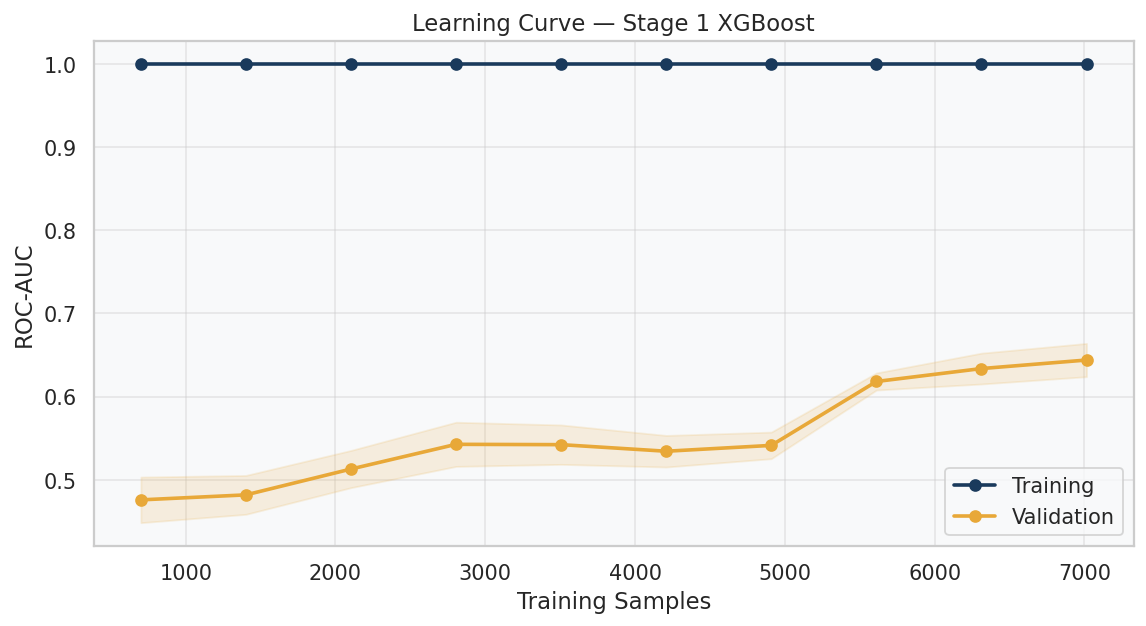

Train AUC : 1.0000  |  Val AUC : 0.6439  |  Gap : 0.3561
Diagnosis : High variance


In [ ]:
lc_model = xgb.XGBClassifier(
    objective="binary:logistic", n_estimators=200, max_depth=6,
    scale_pos_weight=CLASS_WEIGHTS_S1[1]/CLASS_WEIGHTS_S1[0],
    use_label_encoder=False, eval_metric="auc",
    random_state=RANDOM_STATE, n_jobs=-1,
)
train_sizes, train_scores, val_scores = learning_curve(
    lc_model, X_train_s1, y_train_s1,
    train_sizes = np.linspace(0.1, 1.0, 10),
    cv          = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring     = "roc_auc",
    n_jobs      = -1,
)
tm, ts = train_scores.mean(axis=1), train_scores.std(axis=1)
vm, vs = val_scores.mean(axis=1),   val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, tm, "o-", color=PALETTE[0], linewidth=2, label="Training")
ax.fill_between(train_sizes, tm-ts, tm+ts, alpha=0.15, color=PALETTE[0])
ax.plot(train_sizes, vm, "o-", color=PALETTE[2], linewidth=2, label="Validation")
ax.fill_between(train_sizes, vm-vs, vm+vs, alpha=0.15, color=PALETTE[2])
ax.set_xlabel("Training Samples"); ax.set_ylabel("ROC-AUC")
ax.set_title("Learning Curve — Stage 1 XGBoost")
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(PATHS["figures"] / "05_learning_curve.png", dpi=130)
plt.show()

gap = tm[-1] - vm[-1]
print(f"Train AUC : {tm[-1]:.4f}  |  Val AUC : {vm[-1]:.4f}  |  Gap : {gap:.4f}")
print("Diagnosis :",
      "High variance" if gap > 0.15
      else "High bias" if vm[-1] < 0.65
      else "Healthy fit ✅")


---
## 🚢 Section 6 — Deployment
> Export all models and dashboard data. Run once after training is complete.


### 6.1 — Save All Models

In [ ]:
# XGBoost models already saved in Sections 4B and 4D
# Save Prophet, SARIMA, and Random Forest

for feeder, m in prophet_models.items():
    fname = feeder.replace(" ","_").replace("/","") + "_prophet.pkl"
    with open(PATHS["models"] / fname, "wb") as f:
        pickle.dump(m, f)

for feeder, m in sarima_models.items():
    fname = feeder.replace(" ","_").replace("/","") + "_sarima.pkl"
    with open(PATHS["models"] / fname, "wb") as f:
        pickle.dump(m, f)

with open(PATHS["models"] / "rf_stage1.pkl", "wb") as f:
    pickle.dump(rf_s1, f)

print("✅ All models saved to models/saved/")
print(f"   xgb_stage1.json      — Stage 1 binary XGBoost")
print(f"   xgb_stage2.json      — Stage 2 fault XGBoost")
print(f"   rf_stage1.pkl        — Stage 1 Random Forest")
print(f"   *_prophet.pkl (×{len(prophet_models)})  — Prophet per feeder")
print(f"   *_sarima.pkl  (×{len(sarima_models)})  — SARIMA per feeder")
print(f"   pipeline_artefacts.json  — feature lists, encodings, thresholds")
print(f"   ensemble_weights.json    — w_ts, w_ml")


✅ All models saved to models/saved/
   xgb_stage1.json      — Stage 1 binary XGBoost
   xgb_stage2.json      — Stage 2 fault XGBoost
   rf_stage1.pkl        — Stage 1 Random Forest
   *_prophet.pkl (×8)  — Prophet per feeder
   *_sarima.pkl  (×6)  — SARIMA per feeder
   pipeline_artefacts.json  — feature lists, encodings, thresholds
   ensemble_weights.json    — w_ts, w_ml


### 6.2 — Export All Dashboard Data

In [ ]:
# 1. Full historical grid with ensemble predictions
grid_df.to_csv(PATHS["dashboard"] / "historical_predictions.csv", index=False)

# 2. Event log with predicted fault type
events_df["predicted_class"] = (
    pd.Series(xgb_s2_best.predict(events_df[FEATURES_S2]))
      .map(LABEL_UNMAP).values
)
events_df["predicted_label"] = events_df.predicted_class.map(LABELS_3)

export_event_cols = [
    "INCIDENCE","DESC_INCIDENCIA","DETECTION_DATE","RESOLUTION_DATE",
    "INSTALATION_1","CAUSE_TYPE","CAUSE_SUBTYPE","CAUSE","INCIDENCE_TYPE",
    "DURATION_HRS","AFFECTED_CUSTOMERS","MAX_DEMAND",
    "LOSS_GWHRS","LOSS_MILLION_KSH","NUMERATOR_SAIFI","NUMERATOR_SAIDI",
    "outage_class","predicted_class","predicted_label",
]
events_df[export_event_cols].to_csv(PATHS["dashboard"] / "events_log.csv", index=False)

# 3. Reliability metrics
reliability.to_csv(PATHS["dashboard"] / "reliability_metrics.csv", index=False)

# 4. SHAP importance (Stage 1)
shap_imp = pd.DataFrame({
    "feature":    FEATURES_S1,
    "importance": np.abs(shap_s1).mean(axis=0),
}).sort_values("importance", ascending=False)
shap_imp.to_csv(PATHS["dashboard"] / "shap_importance_s1.csv", index=False)

# 5. Network topology — copy from processed to dashboard
for fname in ["feeder_lines.csv","network_nodes.csv","feeder_topology.csv"]:
    src = PATHS["processed"] / fname
    if src.exists():
        shutil.copy(src, PATHS["dashboard"] / fname)

# Verify all dashboard files
print("Dashboard export verification:")
files_expected = [
    "historical_predictions.csv","events_log.csv","reliability_metrics.csv",
    "shap_importance_s1.csv","7day_forecast.csv",
    "feeder_lines.csv","network_nodes.csv","feeder_topology.csv",
]
for fname in files_expected:
    p    = PATHS["dashboard"] / fname
    size = round(p.stat().st_size / 1024, 1) if p.exists() else 0
    print(f"  {'✅' if p.exists() else '❌'}  {fname:<45} {size} KB")


Dashboard export verification:
  ✅  historical_predictions.csv                    4373.2 KB
  ✅  events_log.csv                                253.3 KB
  ✅  reliability_metrics.csv                       2.7 KB
  ✅  shap_importance_s1.csv                        1.1 KB
  ✅  7day_forecast.csv                             20.0 KB
  ✅  feeder_lines.csv                              116.1 KB
  ✅  network_nodes.csv                             74.3 KB
  ✅  feeder_topology.csv                           0.5 KB


### 6.3 — Inference Function

In [ ]:
def predict_outage(feeder, date_str, weather_row, history=None):
    """
    Run the full two-stage pipeline for a single feeder on a specific date.

    Parameters
    ----------
    feeder      : str   — feeder name (must be in ACTIVE_FEEDERS)
    date_str    : str   — 'YYYY-MM-DD'
    weather_row : dict  — daily weather keys matching weather CSV columns
    history     : dict  — optional: outages_last_7d, outages_last_30d,
                                    days_since_last_outage, duration_last_7d_hrs

    Returns
    -------
    dict  — outage_probability, outage_predicted, fault_class,
            fault_label, fault_probabilities, crew_recommendation
    """
    if history is None:
        history = {"outages_last_7d":0, "outages_last_30d":0,
                   "days_since_last_outage":30, "duration_last_7d_hrs":0.0}

    d           = pd.Timestamp(date_str)
    season      = SEASON_MAP[d.month]
    outage_rate = grid_df[grid_df.feeder == feeder].had_outage.mean()
    topo_row    = topology[topology.feeder_name == feeder].iloc[0]

    feat = {
        "feeder_id":              FEEDER_CODES_GLOBAL.get(feeder, -1),
        "max_demand_kva":         FEEDER_STATIC[feeder]["max_demand_kva"],
        "affected_customers":     FEEDER_STATIC[feeder]["affected_customers"],
        "total_length_km":        topo_row.total_length_km,
        "n_secondary_subs":       topo_row.n_secondary_subs,
        "n_switches":             topo_row.n_switches,
        "avg_segment_m":          topo_row.avg_segment_m,
        "bbox_area_km2":          topo_row.bbox_area_km2,
        "year":                   d.year,
        "month":                  d.month,
        "day_of_week":            d.dayofweek,
        "dow":                    d.dayofweek,  # Added missing feature for Stage 2
        "day_of_year":            d.dayofyear,
        "is_weekend":             int(d.dayofweek >= 5),
        "month_sin":              np.sin(2*np.pi*d.month/12),
        "month_cos":              np.cos(2*np.pi*d.month/12),
        "dow_sin":                np.sin(2*np.pi*d.dayofweek/7),
        "dow_cos":                np.cos(2*np.pi*d.dayofweek/7),
        "season_long_dry":        int(season=="long_dry"),
        "season_long_rains":      int(season=="long_rains"),
        "season_short_dry":       int(season=="short_dry"),
        "season_short_rains":     int(season=="short_rains"),
        "outages_last_7d":        history.get("outages_last_7d", 0),
        "outages_last_30d":       history.get("outages_last_30d", 0),
        "duration_last_7d_hrs":   history.get("duration_last_7d_hrs", 0.0),
        "days_since_last_outage": history.get("days_since_last_outage", 30),
        "consecutive_clean_days": history.get("days_since_last_outage", 30),
        "precipitation_sum":      weather_row.get("precipitation_sum", 0),
        "wind_speed_10m_max":     weather_row.get("wind_speed_10m_max", 0),
        "wind_gusts_10m_max":     weather_row.get("wind_gusts_10m_max", 0),
        "et0_fao_evapotranspiration": weather_row.get("et0_fao_evapotranspiration", 3.0),
        "heavy_rain_day":         int(weather_row.get("precipitation_sum", 0) > 10),
        "high_wind_day":          int(weather_row.get("wind_gusts_10m_max", 0) > 10),
        "is_public_holiday":      weather_row.get("is_public_holiday", 0),
        "is_long_weekend":        weather_row.get("is_long_weekend", 0),
        "days_to_next_holiday":   weather_row.get("days_to_next_holiday", 14),
        "days_since_holiday":     weather_row.get("days_since_holiday", 14),
        "feeder_outage_rate":     round(outage_rate, 6),
        "storm_index":            (weather_row.get("precipitation_sum", 0) *
                                   weather_row.get("wind_gusts_10m_max", 0)),
        "rain_season_interaction":(int(season=="long_rains") *
                                   weather_row.get("precipitation_sum", 0)),
        "demand_risk_score":      FEEDER_STATIC[feeder]["max_demand_kva"] * outage_rate,
        "overdue_pressure":       (history.get("days_since_last_outage", 30) *
                                   history.get("outages_last_30d", 0)),
        "length_x_outage_rate":   topo_row.total_length_km * outage_rate,
    }

    # Stage 1: ensemble probability
    X_s1      = pd.DataFrame([feat])[FEATURES_S1]
    prob_xgb  = float(xgb_s1_best.predict_proba(X_s1)[0, 1])
    prob_rf   = float(rf_s1.predict_proba(X_s1)[0, 1])
    prob_ml   = (prob_xgb + prob_rf) / 2

    future   = pd.DataFrame({"ds": [d]})
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fc_p = prophet_models[feeder].predict(future)
    prob_ts   = float(np.clip(fc_p["yhat"].values[0], 0, None))

    w_ts       = ENSEMBLE_WEIGHTS.get("w_ts", 0.3)
    w_ml       = ENSEMBLE_WEIGHTS.get("w_ml", 0.7)
    prob_final = round(w_ts * prob_ts + w_ml * prob_ml, 4)
    flag       = int(prob_final >= OUTAGE_THRESHOLD)

    # Stage 2: fault type (only if flagged)
    fault_class, fault_label, fault_probs, crew = 0, "No Outage Predicted", {}, CREW_MAP[0]
    if flag:
        s2_feat = dict(feat)
        s2_feat.update({
            "hour": 9, "hour_sin": np.sin(2*np.pi*9/24), "hour_cos": np.cos(2*np.pi*9/24),
            "events_last_7d":  history.get("outages_last_7d", 0),
            "events_last_30d": history.get("outages_last_30d", 0),
            "days_since_last": history.get("days_since_last_outage", 30),
            "feeder_event_share": outage_rate,
            "demand_load_factor": (FEEDER_STATIC[feeder]["max_demand_kva"] *
                                   history.get("outages_last_30d", 0)),
        })
        X_s2       = pd.DataFrame([s2_feat])[FEATURES_S2]
        proba_s2   = xgb_s2_best.predict_proba(X_s2)[0]
        pred_s2    = int(np.argmax(proba_s2))
        fault_class = LABEL_UNMAP[pred_s2]
        fault_label = LABELS_3[fault_class]
        fault_probs = {LABELS_3[i+1]: round(float(p), 4) for i, p in enumerate(proba_s2)}
        crew        = CREW_MAP[fault_class]

    return {
        "feeder":              feeder,
        "date":                date_str,
        "outage_probability":  prob_final,
        "outage_predicted":    bool(flag),
        "fault_class":         fault_class,
        "fault_label":         fault_label,
        "fault_probabilities": fault_probs,
        "crew_recommendation": crew,
    }

# Smoke test on a stormy evening scenario
result = predict_outage(
    feeder      = "SOWETO EX LANGATA",
    date_str    = "2026-05-10",
    weather_row = {"precipitation_sum":14.0, "wind_gusts_10m_max":12.5,
                   "wind_speed_10m_max":7.0,  "et0_fao_evapotranspiration":3.2},
    history     = {"outages_last_7d":2, "outages_last_30d":6,
                   "days_since_last_outage":3, "duration_last_7d_hrs":4.2},
)
print("=== INFERENCE TEST ===")
for k, v in result.items():
    print(f"  {k:<25}: {v}")

=== INFERENCE TEST ===
  feeder                   : SOWETO EX LANGATA
  date                     : 2026-05-10
  outage_probability       : 0.3712
  outage_predicted         : True
  fault_class              : 1
  fault_label              : Loss of Supply
  fault_probabilities      : {'Loss of Supply': 0.6444, 'Controlled Interruption': 0.3097, 'Physical Fault': 0.0459}
  crew_recommendation      : System engineers (grid-side fault)


---
## ✅ Notebook Complete

### Summary of outputs

| Section | Output | Saved to |
|---|---|---|
| 3 | `feeder_day_frame.csv` | `data/processed/` |
| 3 | `events_features.csv` | `data/processed/` |
| 4A | Prophet × 8 + SARIMA × 6 | `models/saved/` |
| 4B | `xgb_stage1.json` + `rf_stage1.pkl` | `models/saved/` |
| 4C | `ensemble_weights.json` | `models/saved/` |
| 4D | `xgb_stage2.json` | `models/saved/` |
| 4E | `7day_forecast.csv` + `pipeline_artefacts.json` | `dashboard/` + `models/saved/` |
| 5 | Evaluation metrics, confusion matrices, SHAP plots | `models/results/` |
| 5 | SAIFI/SAIDI table | `models/results/` |
| 6 | All 8 dashboard CSVs | `outputs/dashboard/` |

### Re-run guide
| Goal | Resume from |
|---|---|
| Full run from scratch | Section 0 → run all |
| Skip EDA | Section 3 |
| Re-train models only | Section 4B (loads CSVs from Drive) |
| Refresh 7-day forecast | Section 4E.1 |
| Refresh dashboard data | Section 6.2 |

> All outputs persist to Google Drive. Colab runtime resets do not lose saved work.


In [4]:
import os

def list_files(startpath):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print(f'{subindent}{f}')

print(f"Contents of {PROJECT_ROOT}:")
list_files(str(PROJECT_ROOT))

Contents of /content/drive/MyDrive/KPLC_Langata_Project:
KPLC_Langata_Project/
    KPLC_Langata_Outage_Prediction (1).ipynb
    data/
        raw/
            incidences_Langata_s_s.xlsx
            Langata-Feeders.dxf
            kenya_holidays.csv
            weather_daily.csv
        processed/
            feeder_lines.csv
            parse_dxf.py
            network_nodes.csv
            feeder_topology.csv
            feeder_day_frame.csv
            events_features.csv
        external/
    models/
        saved /
        results/
            4C_precision_recall.png
            05_evaluation_summary.csv
            05_confusion_matrices.png
            05_shap_stage1.png
            05_shap_stage2.png
            05_per_feeder_metrics.csv
            05_saifi_saidi.csv
        saved/
            xgb_stage1.json
            ensemble_weights.json
            xgb_stage2.json
            pipeline_artefacts.json
            HARDY_EX_LANGATA_prophet.pkl
            KAREN_HOSPITAL_EX_LA

### 7.1 — Git Configuration & .gitignore
Configure your GitHub credentials and set up the exclusion list.

In [5]:
import os
from pathlib import Path

# --- EDIT THESE ---
GITHUB_USER  = "your_github_username"
GITHUB_EMAIL = "your_email@example.com"
REPO_NAME    = "KPLC_Langata_Project"
# ------------------

# 1. Configure Git Global Identity
!git config --global user.email "{GITHUB_EMAIL}"
!git config --global user.name "{GITHUB_USER}"

# 2. Create .gitignore in Project Root
gitignore_content = """# Data
data/raw/
*.xlsx
*.csv
!outputs/dashboard/*.csv

# Models
models/saved/
*.pkl
*.json

# Environment & Colab
.ipynb_checkpoints/
__pycache__/
.env
"""

# Fix: Ensure PROJECT_ROOT is handled as a Path object
with open(Path(PROJECT_ROOT) / ".gitignore", "w") as f:
    f.write(gitignore_content)

# 3. Fix the previous commit (untrack files that should be ignored)
%cd {PROJECT_ROOT}
!git rm -r --cached . > /dev/null
!git add .
!git commit -m "Apply .gitignore and remove large binaries from tracking"

print(f"✅ .gitignore created and repository cleaned at {PROJECT_ROOT}")

TypeError: unsupported operand type(s) for /: 'str' and 'str'

### 7.2 — Initialize and Push
This will initialize the repo locally and provide the instructions for the final push. **Note:** You will need a Personal Access Token (PAT) from GitHub to authenticate.

In [6]:
%cd {PROJECT_ROOT}

# Initialize and add files
!git init
!git add .
!git commit -m "Initial commit: KPLC Langata Power Outage Prediction System"

print("\n--- NEXT STEPS ---")
print("1. Create a new repository on GitHub named '" + REPO_NAME + "'.")
print("2. Run the following command in a new cell with your GitHub Token:")
print(f"!git remote add origin https://<TOKEN>@github.com/{GITHUB_USER}/{REPO_NAME}.git")
print("!git branch -M main")
print("!git push -u origin main")

/content/drive/MyDrive/KPLC_Langata_Project
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/drive/MyDrive/KPLC_Langata_Project/.git/
[master (root-commit) 6f4f426] Initial commit: KPLC Langata Power Outage Prediction System
 59 files changed, 436467 insertions(+)
 create mode 100644 KPLC_Langata_Outage_Prediction (1).ipynb
 create mode 100644 dashboard/README.md
 create mode 100644 dashboard/app.py
 create mode 100644 dashboard/data/feeder_lines.csv
 create mode 100644 dashboard/data/feeder_topology.csv
 create m